In [1]:
# ============================================================
# ONE-CELL ALPACA STATIONARY POINT DIAGNOSTIC
# ETF-theme-first + stock-level daily universe
# Finds confirmed maxima/minima and where bot would buy/sell
# ============================================================

# If needed, uncomment this once:
# !pip install alpaca-py

import os
import getpass
import numpy as np
import pandas as pd
from pathlib import Path

from datetime import datetime, timedelta, time, date
from zoneinfo import ZoneInfo

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from alpaca.data.enums import DataFeed


# ============================================================
# 1. USER SETTINGS
# ============================================================

NY_TZ = ZoneInfo("America/New_York")

# ------------------------------------------------------------
# ETF-theme-first daily universe settings
# ------------------------------------------------------------
# FAST SINGLE-DAY DESIGN
#
# ETF/theme ranking does NOT download ETF candles/bars.
# It uses the editable non-candle summary scores below.
#
# Intraday candle data is downloaded ONLY for:
#   1. the final selected stocks, and
#   2. the mapped inverse ETF that may be traded after a drawdown switch,
# and ONLY for the target trading day.
#
# The bot checks each new 1-minute candle and acts when a stationary point
# is confirmed. There is no fixed 15-minute decision interval.

# Sector / market ETFs are kept as labels only in this fast version.
# They are NOT downloaded as candles for ranking or intraday guarding.
GROUP_ETFS = {
    # Broad market regime
    "S&P 500": "SPY",
    "Nasdaq 100": "QQQ",
    "Russell 2000": "IWM",

    # Core sectors
    "Technology": "XLK",
    "Communication Services": "XLC",
    "Consumer Discretionary": "XLY",
    "Consumer Staples": "XLP",
    "Energy": "XLE",
    "Financials": "XLF",
    "Healthcare": "XLV",
    "Industrials": "XLI",
    "Materials": "XLB",
    "Real Estate": "XLRE",
    "Utilities": "XLU",
}

# ETFs used to choose the current market theme.
# These are intentionally hard-coded. They are not the traded stocks;
# they are only "battlefield"/theme detectors.
POPULAR_ETFS_FOR_UNIVERSE = {
    "S&P 500": "SPY",
    "Nasdaq 100": "QQQ",
    "Technology": "XLK",
    "Semiconductors": "SMH",
    "Energy": "XLE",
    "Financials": "XLF",
    "Healthcare": "XLV",
    "Consumer Discretionary": "XLY",
    "Communication Services": "XLC",
    "Industrials": "XLI",
}

# Inverse ETF used if the portfolio drawdown triggers bearish/inverse mode.
# This is NOT used for ETF/theme ranking.
# It is only downloaded as a tradable instrument for SINGLE_TEST_DAY.
INVERSE_ETF_MAP = {
    "QQQ": "SQQQ",   # Nasdaq 100 inverse, leveraged
    "SPY": "SH",     # S&P 500 inverse, non-leveraged
    "IWM": "RWM",    # Russell 2000 inverse, non-leveraged
    "SMH": "SOXS",   # Semiconductor inverse, leveraged
    "XLK": "TECS",   # Technology inverse, leveraged
    "XLF": "SKF",    # Financials inverse, leveraged
    "XLE": "ERY",    # Energy inverse, leveraged
    "XLV": "RXD",    # Healthcare inverse, leveraged
    "XLY": "SCC",    # Consumer discretionary inverse, leveraged
    "XLC": "N/A",    # No simple liquid default here; code will stay in cash if N/A.
    "XLI": "SIJ",    # Industrials inverse, leveraged
}

# ------------------------------------------------------------------
# NON-CANDLE ETF/THEME RANKING INPUT
# ------------------------------------------------------------------
# Edit these numbers before running if you want a different theme.
# Higher score = stronger preferred theme.
#
# Important: this table is deliberately NOT built from candle/bar data.
# It is just a summary ranking input, so ETF sorting does not trigger
# ETF candle downloads.
ETF_THEME_SUMMARY_GROWTH = {
    "Semiconductors": 0.18,
    "Technology": 0.15,
    "Nasdaq 100": 0.12,
    "Communication Services": 0.09,
    "Consumer Discretionary": 0.06,
    "Industrials": 0.05,
    "Financials": 0.04,
    "S&P 500": 0.03,
    "Healthcare": 0.02,
    "Energy": 0.01,
}

# Curated liquid stock lists used after the non-candle ETF/theme ranking.
# The code picks from the strongest theme first, then downloads same-day
# 1-minute candles only for the selected tickers.
CURATED_THEME_STOCKS = {
    "Semiconductors": ["NVDA", "AMD", "AVGO", "QCOM", "MU"],
    "Technology": ["MSFT", "AAPL", "NVDA", "AVGO", "ORCL"],
    "Nasdaq 100": ["MSFT", "AAPL", "NVDA", "AMZN", "GOOGL"],
    "Communication Services": ["GOOGL", "META", "NFLX", "TMUS", "DIS"],
    "Consumer Discretionary": ["AMZN", "TSLA", "HD", "MCD", "NKE"],
    "Industrials": ["GE", "CAT", "RTX", "HON", "UNP"],
    "Financials": ["JPM", "BAC", "WFC", "GS", "MS"],
    "Healthcare": ["LLY", "UNH", "JNJ", "ABBV", "MRK"],
    "Energy": ["XOM", "CVX", "COP", "SLB", "EOG"],
    "S&P 500": ["MSFT", "AAPL", "NVDA", "AMZN", "GOOGL"],
}

STOCK_SECTOR_FALLBACK = {
    "NVDA": "Information Technology", "AMD": "Information Technology", "AVGO": "Information Technology",
    "QCOM": "Information Technology", "MU": "Information Technology", "MSFT": "Information Technology",
    "AAPL": "Information Technology", "ORCL": "Information Technology",
    "AMZN": "Consumer Discretionary", "TSLA": "Consumer Discretionary", "HD": "Consumer Discretionary",
    "MCD": "Consumer Discretionary", "NKE": "Consumer Discretionary",
    "GOOGL": "Communication Services", "META": "Communication Services", "NFLX": "Communication Services",
    "TMUS": "Communication Services", "DIS": "Communication Services",
    "GE": "Industrials", "CAT": "Industrials", "RTX": "Industrials", "HON": "Industrials", "UNP": "Industrials",
    "JPM": "Financials", "BAC": "Financials", "WFC": "Financials", "GS": "Financials", "MS": "Financials",
    "LLY": "Health Care", "UNH": "Health Care", "JNJ": "Health Care", "ABBV": "Health Care", "MRK": "Health Care",
    "XOM": "Energy", "CVX": "Energy", "COP": "Energy", "SLB": "Energy", "EOG": "Energy",
}

# Approximate mapping from an ETF theme to S&P 500 sectors/sub-industries.
# This avoids needing to download ETF holdings. The ETF chooses the theme;
# the stock-level final_score still chooses the actual stocks.
THEME_TO_ALLOWED_SECTORS = {
    "S&P 500": None,          # broad theme: no sector restriction
    "Russell 2000": None,     # broad/risk-on theme: no sector restriction
    "Nasdaq 100": ["Information Technology", "Communication Services", "Consumer Discretionary"],
    "Technology": ["Information Technology"],
    "Semiconductors": ["Information Technology"],
    "Energy": ["Energy"],
    "Financials": ["Financials"],
    "Healthcare": ["Health Care"],
    "Consumer Discretionary": ["Consumer Discretionary"],
    "Communication Services": ["Communication Services"],
    "Industrials": ["Industrials"],
}

THEME_TO_SUB_INDUSTRY_KEYWORDS = {
    "Semiconductors": ["semiconductor", "semiconductors", "semiconductor equipment"],
}

SECTOR_TO_ETF = {
    "Information Technology": "XLK",
    "Communication Services": "XLC",
    "Consumer Discretionary": "XLY",
    "Consumer Staples": "XLP",
    "Energy": "XLE",
    "Financials": "XLF",
    "Health Care": "XLV",
    "Industrials": "XLI",
    "Materials": "XLB",
    "Real Estate": "XLRE",
    "Utilities": "XLU",
}

# ------------------------------------------------------------
# ETF-theme-first dynamic universe settings
# ------------------------------------------------------------
# New method:
#   1) Fetch S&P 500 constituents dynamically.
#   2) Rank S&P 500 stocks by recent average dollar volume.
#   3) Keep the top 65 as a high-quality liquid stock pool.
#   4) Rank the hard-coded ETF themes by medium-term growth.
#   5) Each day, prioritise stocks related to the strongest ETF theme.
#   6) Inside that theme, use the existing stock-level final_score:
#        - historical stationary-point suitability proxy
#        - daily strength / relative momentum
#        - tradable volatility
#        - market / sector confirmation
#        - gap penalty
#   7) Pick the top 5 for that day.

TOP_SP500_STOCK_COUNT = 65
MAX_STOCKS_PER_DAY = 5
MAX_STOCKS_PER_SECTOR = 5  # ETF-theme-first selection can intentionally concentrate.

# ETF theme ranking. 126 trading days is roughly 6 months.
ETF_GROWTH_LOOKBACK_BARS = 126
ETF_GROWTH_LOOKBACK_CALENDAR_DAYS = 220
MIN_ETF_GROWTH_BARS = 20

# If True, theme-matching stocks are considered first. If fewer than 5 are available,
# the selector fills from the broader top-65 pool.
PRIORITISE_STRONGEST_ETF_THEME = True

# Used to form the top-65 candidate pool before the backtest starts.
LIQUIDITY_LOOKBACK_DAYS = 60
MIN_LIQUIDITY_DAILY_BARS = 10

# 1-minute bar reliability settings.
# These do NOT guarantee every future minute will have a bar, but they make the
# daily selector prefer tickers that have reliable 1-minute data.
#
# Important anti-lookahead rule:
#   - same-day selection may use warm-up bars that have already occurred
#   - same-day selection should NOT require the full day's final bar coverage
#   - historical coverage is shifted by one day before being used in selection
MIN_WARMUP_1MIN_BAR_COVERAGE_FOR_SELECTION = 0.60
MIN_HIST_1MIN_BAR_COVERAGE_FOR_SELECTION = 0.70
MIN_HIST_1MIN_BAR_DAYS_FOR_SELECTION = 2
DATA_QUALITY_SCORE_WEIGHT = 0.15

# Live/backtest buy guard: do not buy if the ticker's latest bar is stale.
MAX_RECENT_BAR_AGE_MINUTES = 2

# Used inside daily scoring.
SUITABILITY_LOOKBACK_DAYS = 8

# Wait after market open before buys are allowed.
# 15 means regular-session signals before 9:45 a.m. New York time are ignored.
MARKET_OPEN_BUFFER_MINUTES = 15

# Final-score weights. These sum to 1 before the gap penalty.
HISTORICAL_SUITABILITY_WEIGHT = 0.60
DAILY_STRENGTH_WEIGHT = 0.20
TRADABLE_VOLATILITY_WEIGHT = 0.10
MARKET_SECTOR_CONFIRMATION_WEIGHT = 0.10

# Gap penalty is subtracted from the final score.
# Keep this moderate: huge gaps are bad, but a tiny/moderate gap can still be useful.
GAP_PENALTY_WEIGHT = 0.20

# Avoid stocks that gap too much relative to their normal daily range.
# Example: 2.0 means the gap is 2.0x recent ATR.
MAX_GAP_VS_ATR = 2.0

# These are populated dynamically in section 8 after the Alpaca client is available.
TICKERS = []
DOWNLOAD_TICKERS = []
SP500_CONSTITUENTS_DF = pd.DataFrame()
TOP_SP500_UNIVERSE_DF = pd.DataFrame()
STOCK_TO_SECTOR = {}
STOCK_TO_SECTOR_ETF = {}
STOCK_TO_SUB_INDUSTRY = {}

# Change this to the trading day you want to test.
#
# This notebook is now forced into FAST SINGLE-DAY mode:
#   - ETF/theme ranking uses ETF_THEME_SUMMARY_GROWTH only. No ETF candle/bar download.
#   - Stock selection happens before intraday data download.
#   - Intraday candle download is only for selected stocks + mapped inverse ETF, and only for SINGLE_TEST_DAY.
RUN_SINGLE_DAY_BACKTEST = True
SINGLE_TEST_DAY = date(2026, 3, 24)

# Kept only for backward compatibility with older helper functions.
# The fast run block below does not use ETF candle/bar history.
ETF_RANKING_LOOKBACK_DAYS = 0

# Daily stock context settings
LIQUIDITY_LOOKBACK_DAYS = 60
ATR_WINDOW = 14

# Daily bars are enough for liquidity / previous close / ATR context.
STOCK_DAILY_CONTEXT_LOOKBACK_DAYS = max(LIQUIDITY_LOOKBACK_DAYS, ATR_WINDOW + 10, 30)

if RUN_SINGLE_DAY_BACKTEST:
    BACKTEST_START_TIME = datetime.combine(SINGLE_TEST_DAY, time(0, 0), tzinfo=NY_TZ)
    BACKTEST_END_TIME = datetime.combine(SINGLE_TEST_DAY + timedelta(days=1), time(0, 0), tzinfo=NY_TZ)

    # Stock minute bars only cover the actual test day.
    STOCK_INTRADAY_START_TIME = BACKTEST_START_TIME
    STOCK_INTRADAY_END_TIME = BACKTEST_END_TIME

    # Historical context windows use daily bars only.
    ETF_RANKING_START_TIME = BACKTEST_START_TIME - timedelta(days=ETF_RANKING_LOOKBACK_DAYS)
    ETF_RANKING_END_TIME = BACKTEST_START_TIME

    STOCK_DAILY_CONTEXT_START_TIME = BACKTEST_START_TIME - timedelta(days=STOCK_DAILY_CONTEXT_LOOKBACK_DAYS)
    STOCK_DAILY_CONTEXT_END_TIME = BACKTEST_START_TIME

    # Kept for backward compatibility in old helper code / printouts.
    START_TIME = STOCK_INTRADAY_START_TIME
    END_TIME = STOCK_INTRADAY_END_TIME
else:
    END_TIME = datetime.now(tz=NY_TZ)
    START_TIME = END_TIME - timedelta(weeks=13)

    BACKTEST_START_TIME = START_TIME
    BACKTEST_END_TIME = END_TIME

    STOCK_INTRADAY_START_TIME = START_TIME
    STOCK_INTRADAY_END_TIME = END_TIME

    ETF_RANKING_START_TIME = START_TIME - timedelta(days=ETF_GROWTH_LOOKBACK_CALENDAR_DAYS)
    ETF_RANKING_END_TIME = END_TIME

    STOCK_DAILY_CONTEXT_START_TIME = START_TIME - timedelta(days=LIQUIDITY_LOOKBACK_DAYS)
    STOCK_DAILY_CONTEXT_END_TIME = START_TIME

# Alpaca can do custom minute bars.
# Try 3, 5, 10, 15, etc.
BAR_MINUTES = 1
TIMEFRAME = TimeFrame(BAR_MINUTES, TimeFrameUnit.Minute)

# If you are on Alpaca free data, use IEX.
# If you have SIP data access, you can change this to DataFeed.SIP.
DATA_FEED = DataFeed.IEX

# Stationary point settings
SMOOTH_WINDOW = 5
VOL_WINDOW = 20
ATR_WINDOW = 14

# ORDER means how many candles on each side are used to confirm a point.
# Example:
# BAR_MINUTES = 5 and ORDER = 3
# means confirmation delay is 15 minutes.
ORDER = 1

# Reject tiny swings.
# 0.001 = 0.1%
# 0.002 = 0.2%
# Set to 0.0 if you want no swing filter.
MIN_SWING_PCT = 0.001


# ============================================================
# 2. ALPACA API KEYS - ASK AT RUNTIME, DO NOT HARDCODE
# ============================================================

import os
import getpass

ALPACA_API_KEY = os.getenv("ALPACA_API_KEY")
ALPACA_SECRET_KEY = os.getenv("ALPACA_SECRET_KEY")

# If environment variables are not set, ask inside VS Code/Jupyter
if not ALPACA_API_KEY:
    ALPACA_API_KEY = getpass.getpass("Enter your Alpaca API key: ")

if not ALPACA_SECRET_KEY:
    ALPACA_SECRET_KEY = getpass.getpass("Enter your Alpaca secret key: ")

if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
    raise ValueError("Alpaca API key or secret key was not provided.")

stock_client = StockHistoricalDataClient(
    ALPACA_API_KEY,
    ALPACA_SECRET_KEY
)

print("Alpaca data client created successfully.")


# ============================================================
# 3. FEATURE FUNCTIONS
# ============================================================

def compute_atr(df, window=14):
    high = df["High"]
    low = df["Low"]
    close = df["Close"]
    prev_close = close.shift(1)

    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()

    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    return true_range.rolling(window=window, min_periods=window).mean()


def prepare_features(df):
    df = df.copy()

    df["smooth_price"] = (
        df["Close"]
        .rolling(window=SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW)
        .mean()
    )

    df["first_derivative"] = df["smooth_price"].diff()
    df["second_derivative"] = df["first_derivative"].diff()

    df["returns"] = df["Close"].pct_change()

    df["rolling_volatility"] = (
        df["returns"]
        .rolling(window=VOL_WINDOW, min_periods=VOL_WINDOW)
        .std()
    )

    df["ATR"] = compute_atr(df, window=ATR_WINDOW)
    df["ATR_percent"] = df["ATR"] / df["Close"]

    return df


# ============================================================
# 4. ALPACA DATA FETCH
# ============================================================

def get_alpaca_stock_bars(symbols, start_time, end_time, timeframe, feed=DataFeed.IEX):
    request = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=timeframe,
        start=start_time,
        end=end_time,
        feed=feed
    )

    bars = stock_client.get_stock_bars(request)
    df = bars.df

    if df.empty:
        return pd.DataFrame()

    df = df.reset_index()

    rename_map = {
        "symbol": "ticker",
        "timestamp": "time",
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume",
        "trade_count": "TradeCount",
        "vwap": "VWAP"
    }

    df = df.rename(columns=rename_map)

    # Convert timestamps to New York time for readability
    if df["time"].dt.tz is None:
        df["time"] = df["time"].dt.tz_localize("UTC")

    df["time"] = df["time"].dt.tz_convert(NY_TZ)

    df = df.sort_values(["ticker", "time"]).reset_index(drop=True)

    return df



# ============================================================
# ============================================================
# 4B. DYNAMIC TOP-65 S&P 500 UNIVERSE + DAILY STOCK SELECTION
# ============================================================

def standardize_symbol_for_alpaca(symbol):
    """
    Standardises ticker symbols from public S&P 500 tables.
    Most symbols are unchanged. This function is kept separate so it is easy
    to adjust if your broker/data feed represents special tickers differently.
    """
    return str(symbol).strip()

SP500_CACHE_PATH = Path("sp500_constituents_cache.csv")

SP500_CSV_URL = (
    "https://raw.githubusercontent.com/datasets/"
    "s-and-p-500-companies/main/data/constituents.csv"
)

def fetch_sp500_constituents(refresh=False):
    """
    Gets the S&P 500 constituent list from a simple GitHub CSV source,
    then saves a local cache.

    This avoids pd.read_html(), so it does not need lxml/html5lib/bs4.
    If the online fetch fails but a cache exists, the cache is used.
    """

    # Use cached copy unless we explicitly ask to refresh
    if SP500_CACHE_PATH.exists() and not refresh:
        print(f"Loading S&P 500 constituents from cache: {SP500_CACHE_PATH}")
        constituents = pd.read_csv(SP500_CACHE_PATH)

    else:
        try:
            print("Fetching S&P 500 constituents from GitHub CSV...")
            constituents = pd.read_csv(SP500_CSV_URL)

            if "Symbol" not in constituents.columns:
                raise ValueError(
                    f"Expected a 'Symbol' column, but got: {constituents.columns.tolist()}"
                )

            constituents.to_csv(SP500_CACHE_PATH, index=False)
            print(f"Saved S&P 500 constituents to cache: {SP500_CACHE_PATH}")

        except Exception as exc:
            print("Online S&P 500 fetch failed:", repr(exc))

            if SP500_CACHE_PATH.exists():
                print(f"Falling back to cached S&P 500 list: {SP500_CACHE_PATH}")
                constituents = pd.read_csv(SP500_CACHE_PATH)
            else:
                raise RuntimeError(
                    "Could not fetch the S&P 500 constituent list and no cache exists. "
                    "Check internet connection, or manually create sp500_constituents_cache.csv."
                ) from exc

    # Standardise columns so the rest of the notebook still works
    rename_map = {
        "Symbol": "ticker",
        "Security": "company",
        "Name": "company",
        "GICS Sector": "sector",
        "Sector": "sector",
        "GICS Sub-Industry": "sub_industry",
        "Sub-Industry": "sub_industry",
    }

    constituents = constituents.rename(
        columns={old: new for old, new in rename_map.items() if old in constituents.columns}
    )

    required_cols = {"ticker", "company", "sector"}
    missing = required_cols - set(constituents.columns)

    if missing:
        raise RuntimeError(
            f"S&P 500 CSV format issue. Missing columns after rename: {missing}. "
            f"Available columns: {constituents.columns.tolist()}"
        )

    if "sub_industry" not in constituents.columns:
        constituents["sub_industry"] = ""

    constituents["ticker"] = (
    constituents["ticker"]
    .astype(str)
    .str.strip()
     )

    constituents["sector_etf"] = constituents["sector"].map(SECTOR_TO_ETF)
    constituents = constituents[constituents["sector_etf"].notna()].copy()

    return (
        constituents[["ticker", "company", "sector", "sector_etf", "sub_industry"]]
        .drop_duplicates("ticker")
        .reset_index(drop=True)
    )

def build_top_sp500_liquidity_universe(sp500_constituents, daily_bars_df, top_n=65):
    """
    Uses recent daily bars to select the top-N S&P 500 stocks by average dollar volume.

    This is the dynamic Tier-1 candidate universe:
        S&P 500 -> top 65 by liquidity / attention.
    """
    if daily_bars_df.empty:
        raise ValueError("daily_bars_df is empty; cannot build top S&P 500 liquidity universe.")

    df = daily_bars_df.copy()
    df["date"] = df["time"].dt.date
    df = df[df["ticker"].isin(sp500_constituents["ticker"])].copy()

    if df.empty:
        raise ValueError("No S&P 500 symbols returned daily bars from Alpaca.")

    df["dollar_volume"] = df["Close"] * df["Volume"]

    liquidity = (
        df.groupby("ticker")
        .agg(
            avg_close=("Close", "mean"),
            avg_volume=("Volume", "mean"),
            avg_dollar_volume=("dollar_volume", "mean"),
            valid_daily_bars=("date", "nunique"),
        )
        .reset_index()
    )

    liquidity = liquidity[liquidity["valid_daily_bars"] >= MIN_LIQUIDITY_DAILY_BARS].copy()

    universe = (
        liquidity
        .merge(sp500_constituents, on="ticker", how="left")
        .sort_values("avg_dollar_volume", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    if universe.empty:
        raise ValueError("Top S&P 500 liquidity universe is empty after filtering.")

    return universe


def build_daily_ohlcv(intraday_df):
    """
    Converts intraday bars into one OHLCV row per ticker per date.
    Used to calculate previous close, previous volume, and ATR-like volatility.
    """
    df = intraday_df.copy()
    df["date"] = df["time"].dt.date

    daily = (
        df.groupby(["ticker", "date"])
        .agg(
            Open=("Open", "first"),
            High=("High", "max"),
            Low=("Low", "min"),
            Close=("Close", "last"),
            Volume=("Volume", "sum")
        )
        .reset_index()
        .sort_values(["ticker", "date"])
    )

    daily["prev_close"] = daily.groupby("ticker")["Close"].shift(1)
    daily["prev_volume"] = daily.groupby("ticker")["Volume"].shift(1)
    daily["prev_dollar_volume"] = daily["prev_close"] * daily["prev_volume"]

    high = daily["High"]
    low = daily["Low"]
    prev_close = daily["prev_close"]

    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()

    daily["true_range"] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    daily["ATR_daily"] = (
        daily.groupby("ticker")["true_range"]
        .transform(lambda s: s.rolling(ATR_WINDOW, min_periods=3).mean())
        .shift(1)
    )
    daily["ATR_percent_daily"] = daily["ATR_daily"] / daily["prev_close"]

    daily["daily_range_pct"] = (daily["High"] - daily["Low"]) / daily["Open"].replace(0, np.nan)

    return daily


def build_stock_daily_context(daily_bars_df, target_dates):
    """
    Builds same-day context rows from historical DAILY stock bars.

    For a target trading date, this provides the previous close, previous volume,
    previous dollar volume, and ATR context without downloading many days of
    1-minute stock candles.
    """
    if daily_bars_df is None or daily_bars_df.empty:
        return pd.DataFrame()

    df = daily_bars_df.copy()
    df["date"] = df["time"].dt.date
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

    df["prev_close_for_tr"] = df.groupby("ticker")["Close"].shift(1)
    tr1 = df["High"] - df["Low"]
    tr2 = (df["High"] - df["prev_close_for_tr"]).abs()
    tr3 = (df["Low"] - df["prev_close_for_tr"]).abs()
    df["true_range"] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    df["ATR_context"] = (
        df.groupby("ticker")["true_range"]
        .transform(lambda s: s.rolling(ATR_WINDOW, min_periods=3).mean())
    )
    df["daily_range_pct_context"] = (
        (df["High"] - df["Low"]) / df["Open"].replace(0, np.nan)
    )

    target_dates = sorted(set(target_dates))
    rows = []

    for target_date in target_dates:
        hist = df[df["date"] < target_date].copy()
        if hist.empty:
            continue

        last = hist.sort_values(["ticker", "date"]).groupby("ticker").tail(1).copy()

        for _, row in last.iterrows():
            prev_close = float(row["Close"]) if pd.notna(row["Close"]) else np.nan
            prev_volume = float(row["Volume"]) if pd.notna(row["Volume"]) else np.nan
            atr_daily = float(row["ATR_context"]) if pd.notna(row["ATR_context"]) else np.nan

            rows.append({
                "ticker": row["ticker"],
                "date": target_date,
                "prev_close": prev_close,
                "prev_volume": prev_volume,
                "prev_dollar_volume": prev_close * prev_volume if np.isfinite(prev_close) and np.isfinite(prev_volume) else np.nan,
                "ATR_daily": atr_daily,
                "ATR_percent_daily": atr_daily / prev_close if np.isfinite(atr_daily) and prev_close > 0 else np.nan,
                "daily_range_pct": float(row["daily_range_pct_context"]) if pd.notna(row["daily_range_pct_context"]) else np.nan,
            })

    return pd.DataFrame(rows)


def first_bar_features(intraday_df):
    """
    Gets the first regular-session bar for each ticker/date.
    In this notebook, this first bar is used as the backtest approximation
    of the at-open / overnight signal.
    """
    df = intraday_df.copy()
    df["date"] = df["time"].dt.date

    first_rows = (
        df.sort_values(["ticker", "time"])
        .groupby(["ticker", "date"])
        .first()
        .reset_index()
    )

    return first_rows[["ticker", "date", "time", "Open", "Close", "Volume"]].rename(
        columns={
            "time": "first_bar_time",
            "Open": "day_open",
            "Close": "first_bar_close",
            "Volume": "first_bar_volume",
        }
    )


def expected_regular_session_bars_for_interval(bar_minutes=None):
    """
    Approximate expected number of regular-session bars for one full US stock day.
    Regular session is 9:30 a.m. to 4:00 p.m. New York time = 390 minutes.
    """
    if bar_minutes is None:
        bar_minutes = BAR_MINUTES

    bar_minutes = max(int(bar_minutes), 1)
    return max(int(390 / bar_minutes), 1)


def expected_warmup_bars_for_interval(bar_minutes=None, buffer_minutes=None):
    """
    Approximate expected bar count between 9:30 a.m. and the buy-start buffer time.
    This is known before the bot starts buying, so it is safe to use for selection.
    """
    if bar_minutes is None:
        bar_minutes = BAR_MINUTES
    if buffer_minutes is None:
        buffer_minutes = MARKET_OPEN_BUFFER_MINUTES

    bar_minutes = max(int(bar_minutes), 1)
    buffer_minutes = max(int(buffer_minutes), 1)

    return max(int(buffer_minutes / bar_minutes), 1)


def build_intraday_quality_features(intraday_df):
    """
    Builds per-ticker, per-day quality features from intraday bars.

    These are historical suitability proxies for the stationary-point bot:
        - enough intraday range
        - enough clean turning-point opportunity
        - not too much random noisy movement
        - enough bars/volume
        - reliable 1-minute / intraday bar coverage

    The bar-coverage features are used so the daily selector prefers stocks
    with reliable 1-minute data. Full-day coverage is recorded for diagnostics
    and shifted for historical use before selection, so it does not need to
    peek into the future for same-day decisions.
    """
    rows = []

    expected_full_day_bars = expected_regular_session_bars_for_interval(BAR_MINUTES)
    expected_warmup_bars = expected_warmup_bars_for_interval(BAR_MINUTES, MARKET_OPEN_BUFFER_MINUTES)

    for (ticker, current_date), day_df in intraday_df.groupby(["ticker", intraday_df["time"].dt.date]):
        day_df = day_df.sort_values("time").copy()

        if len(day_df) < max(6, SMOOTH_WINDOW + 2):
            continue

        unique_bar_times = pd.Series(day_df["time"].dropna().unique()).sort_values()

        valid_intraday_bars = int(len(unique_bar_times))
        bar_coverage = min(valid_intraday_bars / expected_full_day_bars, 1.0)

        market_open = datetime.combine(current_date, time(9, 30), tzinfo=NY_TZ)
        warmup_end = market_open + timedelta(minutes=MARKET_OPEN_BUFFER_MINUTES)

        warmup_bars = day_df[
            (day_df["time"] >= market_open)
            & (day_df["time"] < warmup_end)
        ]

        valid_warmup_bars = int(warmup_bars["time"].nunique())
        warmup_bar_coverage = min(valid_warmup_bars / expected_warmup_bars, 1.0)

        if len(unique_bar_times) >= 2:
            bar_gaps_minutes = unique_bar_times.diff().dropna().dt.total_seconds() / 60.0
            max_bar_gap_minutes = float(bar_gaps_minutes.max())
            avg_bar_gap_minutes = float(bar_gaps_minutes.mean())
        else:
            max_bar_gap_minutes = np.nan
            avg_bar_gap_minutes = np.nan

        # Penalise stale/missing stretches. A perfect score is close to 1.
        # For 1-minute bars, a max gap of >= 5 minutes receives a large penalty.
        if np.isfinite(max_bar_gap_minutes):
            gap_penalty_component = 1.0 - min(max(max_bar_gap_minutes - BAR_MINUTES, 0.0) / 5.0, 1.0)
        else:
            gap_penalty_component = 0.0

        bar_quality_score = (
            0.55 * bar_coverage
            + 0.35 * warmup_bar_coverage
            + 0.10 * gap_penalty_component
        )

        close = day_df["Close"].astype(float)
        smooth = close.rolling(SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW).mean()

        # Simple approximate turning-point count for suitability only.
        approx_min = (smooth.shift(1) > smooth) & (smooth.shift(-1) > smooth)
        approx_max = (smooth.shift(1) < smooth) & (smooth.shift(-1) < smooth)
        approx_extrema_count = int((approx_min | approx_max).sum())

        open_price = float(day_df["Open"].iloc[0])
        close_price = float(day_df["Close"].iloc[-1])
        high_price = float(day_df["High"].max())
        low_price = float(day_df["Low"].min())

        intraday_range_pct = (high_price - low_price) / open_price if open_price else np.nan
        abs_bar_move_sum = close.pct_change().abs().sum()
        abs_open_to_close_move = abs(close_price / open_price - 1.0) if open_price else np.nan

        # Larger values mean more random back-and-forth relative to net movement.
        # Some back-and-forth is good for stationary points; extreme values are noisy.
        choppiness = abs_bar_move_sum / (abs_open_to_close_move + 0.001)

        rows.append({
            "ticker": ticker,
            "date": current_date,
            "intraday_range_pct": intraday_range_pct,
            "approx_extrema_count": approx_extrema_count,
            "choppiness": choppiness,
            "valid_intraday_bars": valid_intraday_bars,
            "expected_intraday_bars": expected_full_day_bars,
            "bar_coverage": bar_coverage,
            "valid_warmup_bars": valid_warmup_bars,
            "expected_warmup_bars": expected_warmup_bars,
            "warmup_bar_coverage": warmup_bar_coverage,
            "max_bar_gap_minutes": max_bar_gap_minutes,
            "avg_bar_gap_minutes": avg_bar_gap_minutes,
            "bar_quality_score": bar_quality_score,
        })

    return pd.DataFrame(rows)


def percentile_rank(series):
    """
    Stable percentile rank helper.
    Higher values get higher ranks.
    """
    return series.rank(pct=True).fillna(0.0)


def _safe_minmax(series):
    """
    Simple 0-1 scaling for one cross-section. Returns 0.5 if all values are equal.
    """
    s = series.astype(float).replace([np.inf, -np.inf], np.nan)
    mn = s.min()
    mx = s.max()

    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(0.5, index=series.index)

    return (s - mn) / (mx - mn)


def stock_matches_etf_theme(row, theme_name):
    """
    Returns True if a stock belongs to the chosen ETF theme.

    This is a practical approximation using S&P 500 sector/sub-industry metadata.
    It avoids downloading ETF holdings while still letting the strongest ETF theme
    focus the universe selection.
    """
    allowed_sectors = THEME_TO_ALLOWED_SECTORS.get(theme_name)

    # Broad themes, such as SPY, do not restrict by sector.
    if allowed_sectors is None:
        return True

    sector = row.get("sector", None)
    sub_industry = str(row.get("sub_industry", "")).lower()

    sector_match = sector in allowed_sectors
    keyword_match = any(
        keyword.lower() in sub_industry
        for keyword in THEME_TO_SUB_INDUSTRY_KEYWORDS.get(theme_name, [])
    )

    # For semiconductor theme, require sub-industry evidence if available.
    if theme_name == "Semiconductors":
        return keyword_match or (sector_match and "semiconductor" in sub_industry)

    return bool(sector_match or keyword_match)


def build_etf_theme_growth_scores(etf_daily_bars_df, backtest_dates):
    """
    Ranks the hard-coded ETF themes by medium-term growth for each backtest day.

    Uses only ETF daily closes strictly before each trading day, so there is no
    same-day lookahead. The strongest ETF becomes the daily market theme.
    """
    if etf_daily_bars_df is None or etf_daily_bars_df.empty:
        return pd.DataFrame()

    df = etf_daily_bars_df.copy()
    df["date"] = df["time"].dt.date
    df = df[df["ticker"].isin(POPULAR_ETFS_FOR_UNIVERSE.values())].copy()
    df = df.sort_values(["ticker", "date"])

    etf_to_theme = {etf: theme for theme, etf in POPULAR_ETFS_FOR_UNIVERSE.items()}
    rows = []

    for current_date in sorted(backtest_dates):
        for etf in POPULAR_ETFS_FOR_UNIVERSE.values():
            hist = df[(df["ticker"] == etf) & (df["date"] < current_date)].copy()
            hist = hist.dropna(subset=["Close"]).sort_values("date")

            if len(hist) < MIN_ETF_GROWTH_BARS:
                continue

            end_close = float(hist["Close"].iloc[-1])

            if len(hist) > ETF_GROWTH_LOOKBACK_BARS:
                start_close = float(hist["Close"].iloc[-ETF_GROWTH_LOOKBACK_BARS - 1])
                bars_used = ETF_GROWTH_LOOKBACK_BARS
            else:
                start_close = float(hist["Close"].iloc[0])
                bars_used = len(hist) - 1

            if start_close <= 0 or not np.isfinite(start_close):
                continue

            growth_return = (end_close / start_close) - 1.0

            rows.append({
                "date": current_date,
                "theme": etf_to_theme.get(etf, etf),
                "theme_etf": etf,
                "etf_growth_return": growth_return,
                "etf_growth_bars_used": bars_used,
                "etf_start_close": start_close,
                "etf_end_close": end_close,
            })

    scores = pd.DataFrame(rows)

    if scores.empty:
        return scores

    scores = scores.sort_values(["date", "etf_growth_return"], ascending=[True, False])
    scores["etf_growth_rank"] = scores.groupby("date")["etf_growth_return"].rank(
        ascending=False,
        method="first"
    )
    scores["is_selected_theme"] = scores["etf_growth_rank"] == 1

    return scores.reset_index(drop=True)


def build_daily_universe_selection(raw_bars_df, etf_theme_scores_df=None, stock_daily_context_df=None):
    """
    Picks a fresh top-5 stock universe for each trading day.

    ETF-theme-first selection method:
        1) Candidate pool is the dynamic top-65 S&P 500 liquidity universe.
        2) ETF themes are ranked by medium-term growth.
        3) Stocks matching the strongest ETF theme are prioritised.
        4) Inside the prioritised theme, each stock gets the existing final_score.
        5) The top 5 are selected for that day.

    Important:
        With IEX data, this uses the first available regular-session bar
        as the opening signal. If you later use reliable pre-market data,
        swap the first-bar signal for true pre-market features.
    """
    bars = raw_bars_df.copy()

    if bars.empty:
        raise ValueError("raw_bars_df is empty; cannot build daily universe.")

    if not TICKERS:
        raise ValueError("TICKERS is empty. Build the dynamic top-65 S&P 500 universe first.")

    daily = build_daily_ohlcv(bars)

    # In fast single-day mode, raw_bars_df only contains the target day
    # 1-minute bars. That means build_daily_ohlcv() cannot infer previous
    # closes/ATR by itself. Fill those fields from historical DAILY bars.
    if stock_daily_context_df is not None and not stock_daily_context_df.empty:
        fallback_cols = [
            "prev_close", "prev_volume", "prev_dollar_volume",
            "ATR_daily", "ATR_percent_daily", "daily_range_pct"
        ]
        daily = daily.merge(
            stock_daily_context_df[["ticker", "date"] + fallback_cols],
            on=["ticker", "date"],
            how="left",
            suffixes=("", "_ctx")
        )

        for col in fallback_cols:
            ctx_col = f"{col}_ctx"
            if ctx_col in daily.columns:
                daily[col] = daily[col].fillna(daily[ctx_col])
                daily = daily.drop(columns=[ctx_col])

    first = first_bar_features(bars)
    quality = build_intraday_quality_features(bars)

    features = first.merge(
        daily[[
            "ticker", "date", "prev_close", "prev_volume", "prev_dollar_volume",
            "ATR_daily", "ATR_percent_daily", "daily_range_pct"
        ]],
        on=["ticker", "date"],
        how="left"
    )

    if not quality.empty:
        features = features.merge(quality, on=["ticker", "date"], how="left")
    else:
        features["intraday_range_pct"] = np.nan
        features["approx_extrema_count"] = np.nan
        features["choppiness"] = np.nan
        features["valid_intraday_bars"] = np.nan
        features["expected_intraday_bars"] = np.nan
        features["bar_coverage"] = np.nan
        features["valid_warmup_bars"] = np.nan
        features["expected_warmup_bars"] = np.nan
        features["warmup_bar_coverage"] = np.nan
        features["max_bar_gap_minutes"] = np.nan
        features["avg_bar_gap_minutes"] = np.nan
        features["bar_quality_score"] = np.nan

    features["open_momentum"] = (
        (features["day_open"] - features["prev_close"]) / features["prev_close"]
    )
    features["gap_pct"] = features["open_momentum"]
    features["gap_vs_atr"] = (
        (features["day_open"] - features["prev_close"]).abs() / features["ATR_daily"]
    )

    features["volatility_score_raw"] = features["ATR_percent_daily"].replace([np.inf, -np.inf], np.nan)
    features["liquidity_score_raw"] = np.log1p(features["prev_dollar_volume"].clip(lower=0))

    # ------------------------------------------------------------------
    # Market / sector ETF confirmation features
    # ------------------------------------------------------------------
    etf_to_group = {etf: group for group, etf in GROUP_ETFS.items()}

    group_features = features[features["ticker"].isin(GROUP_ETFS.values())].copy()
    group_features["group"] = group_features["ticker"].map(etf_to_group)

    group_feature_rows = []

    for current_date, day_group_df in group_features.groupby("date"):
        day_group_df = day_group_df.copy()
        day_group_df["momentum_rank"] = percentile_rank(day_group_df["open_momentum"])
        day_group_df["volatility_rank"] = percentile_rank(day_group_df["volatility_score_raw"])
        day_group_df["gap_penalty_rank"] = percentile_rank(day_group_df["gap_pct"].abs())

        day_group_df["group_score"] = (
            0.65 * day_group_df["momentum_rank"]
            + 0.25 * day_group_df["volatility_rank"]
            - 0.10 * day_group_df["gap_penalty_rank"]
        )

        group_feature_rows.append(day_group_df.sort_values("group_score", ascending=False))

    group_scores_df = (
        pd.concat(group_feature_rows, ignore_index=True)
        if group_feature_rows
        else pd.DataFrame()
    )

    # Maps used for daily confirmation.
    sp500_momentum_by_date = {}
    qqq_momentum_by_date = {}
    sector_momentum_by_date_and_etf = {}

    if not group_scores_df.empty:
        spy_rows = group_scores_df[group_scores_df["ticker"] == "SPY"]
        qqq_rows = group_scores_df[group_scores_df["ticker"] == "QQQ"]

        sp500_momentum_by_date = dict(zip(spy_rows["date"], spy_rows["open_momentum"]))
        qqq_momentum_by_date = dict(zip(qqq_rows["date"], qqq_rows["open_momentum"]))

        for _, row in group_scores_df.iterrows():
            sector_momentum_by_date_and_etf[(row["date"], row["ticker"])] = row["open_momentum"]

    # ------------------------------------------------------------------
    # Strongest ETF theme per day.
    # ------------------------------------------------------------------
    selected_theme_by_date = {}

    if etf_theme_scores_df is not None and not etf_theme_scores_df.empty:
        selected_theme_rows = etf_theme_scores_df[etf_theme_scores_df["is_selected_theme"]].copy()
        for _, row in selected_theme_rows.iterrows():
            selected_theme_by_date[row["date"]] = {
                "selected_theme": row["theme"],
                "selected_theme_etf": row["theme_etf"],
                "selected_theme_growth": row["etf_growth_return"],
                "selected_theme_growth_bars_used": row["etf_growth_bars_used"],
            }

    # ------------------------------------------------------------------
    # Historical suitability features.
    # All suitability columns are shifted by 1 day, so each day only uses
    # earlier information.
    # ------------------------------------------------------------------
    stock_features = features[features["ticker"].isin(TICKERS)].copy()
    stock_features = stock_features.sort_values(["ticker", "date"]).reset_index(drop=True)

    rolling_cols = {
        "prev_dollar_volume": "hist_dollar_volume",
        "ATR_percent_daily": "hist_atr_pct",
        "daily_range_pct": "hist_range_pct",
        "approx_extrema_count": "hist_extrema_count",
        "choppiness": "hist_choppiness",
        "valid_intraday_bars": "hist_valid_bars",
        "bar_coverage": "hist_bar_coverage",
        "warmup_bar_coverage": "hist_warmup_bar_coverage",
        "bar_quality_score": "hist_bar_quality_score",
    }

    for source_col, target_col in rolling_cols.items():
        stock_features[target_col] = (
            stock_features.groupby("ticker")[source_col]
            .transform(lambda s: s.shift(1).rolling(SUITABILITY_LOOKBACK_DAYS, min_periods=2).mean())
        )

    # Number of previous trading days that contributed to historical bar-quality stats.
    # This is used to avoid over-trusting one accidental good/bad day.
    stock_features["hist_bar_observation_days"] = (
        stock_features.groupby("ticker")["bar_coverage"]
        .transform(lambda s: s.shift(1).rolling(SUITABILITY_LOOKBACK_DAYS, min_periods=1).count())
    )

    stock_features["sector"] = stock_features["ticker"].map(STOCK_TO_SECTOR)
    stock_features["sector_etf"] = stock_features["ticker"].map(STOCK_TO_SECTOR_ETF)
    stock_features["sub_industry"] = stock_features["ticker"].map(STOCK_TO_SUB_INDUSTRY)

    selected_rows = []
    scoring_rows = []

    for current_date, day_stock_df in stock_features.groupby("date"):
        day_stock_df = day_stock_df.copy()

        if day_stock_df.empty:
            continue

        theme_info = selected_theme_by_date.get(current_date, {
            "selected_theme": "S&P 500",
            "selected_theme_etf": "SPY",
            "selected_theme_growth": np.nan,
            "selected_theme_growth_bars_used": np.nan,
        })

        selected_theme = theme_info["selected_theme"]
        day_stock_df["selected_theme"] = selected_theme
        day_stock_df["selected_theme_etf"] = theme_info["selected_theme_etf"]
        day_stock_df["selected_theme_growth"] = theme_info["selected_theme_growth"]
        day_stock_df["selected_theme_growth_bars_used"] = theme_info["selected_theme_growth_bars_used"]
        day_stock_df["theme_match"] = day_stock_df.apply(
            lambda row: stock_matches_etf_theme(row, selected_theme),
            axis=1
        )

        # Daily relative strength.
        spy_mom = sp500_momentum_by_date.get(current_date, 0.0)
        qqq_mom = qqq_momentum_by_date.get(current_date, 0.0)

        day_stock_df["spy_open_momentum"] = spy_mom
        day_stock_df["qqq_open_momentum"] = qqq_mom
        day_stock_df["sector_open_momentum"] = day_stock_df["sector_etf"].apply(
            lambda etf: sector_momentum_by_date_and_etf.get((current_date, etf), 0.0)
        )

        day_stock_df["relative_strength_vs_spy"] = day_stock_df["open_momentum"] - day_stock_df["spy_open_momentum"]
        day_stock_df["relative_strength_vs_qqq"] = day_stock_df["open_momentum"] - day_stock_df["qqq_open_momentum"]
        day_stock_df["relative_strength_vs_sector"] = day_stock_df["open_momentum"] - day_stock_df["sector_open_momentum"]

        # Do not select deeply weak stocks. Slightly negative stocks can still rank
        # if they are strong relative to SPY/sector.
        day_stock_df = day_stock_df[
            (day_stock_df["open_momentum"] > -0.0075)
            & (day_stock_df["relative_strength_vs_sector"] > -0.0075)
        ].copy()

        # Avoid extremely stretched gaps unless ATR is unavailable.
        day_stock_df = day_stock_df[
            (day_stock_df["gap_vs_atr"].isna())
            | (day_stock_df["gap_vs_atr"] <= MAX_GAP_VS_ATR)
        ].copy()

        # Prefer/restrict to names with reliable intraday bar availability.
        # For 1-minute mode, this is especially important: a missing/stale 1-minute
        # stream can make stationary-point signals unreliable.
        #
        # Anti-lookahead:
        #   - same-day warm-up coverage is known before buys are allowed
        #   - historical coverage is shifted by 1 day before being used
        #   - same-day full-day coverage is displayed but not required here
        if BAR_MINUTES == 1:
            enough_hist_days = (
                day_stock_df["hist_bar_observation_days"].fillna(0)
                >= MIN_HIST_1MIN_BAR_DAYS_FOR_SELECTION
            )

            # If enough prior days exist, require good historical bar coverage.
            # If not enough prior days exist, fall back to same-day warm-up coverage.
            hist_bar_ok = (
                ~enough_hist_days
                | (day_stock_df["hist_bar_coverage"] >= MIN_HIST_1MIN_BAR_COVERAGE_FOR_SELECTION)
            )

            warmup_ok = (
                day_stock_df["warmup_bar_coverage"].fillna(0.0)
                >= MIN_WARMUP_1MIN_BAR_COVERAGE_FOR_SELECTION
            )

            day_stock_df = day_stock_df[
                hist_bar_ok
                & warmup_ok
            ].copy()

        if day_stock_df.empty:
            continue

        # Historical suitability score components.
        day_stock_df["hist_liquidity_rank"] = percentile_rank(day_stock_df["hist_dollar_volume"])
        day_stock_df["hist_range_rank"] = percentile_rank(day_stock_df["hist_range_pct"])
        day_stock_df["hist_volatility_rank"] = percentile_rank(day_stock_df["hist_atr_pct"])
        day_stock_df["hist_extrema_rank"] = percentile_rank(day_stock_df["hist_extrema_count"])

        # Lower choppiness is cleaner, but completely smooth/trend-only stocks may have fewer extrema.
        # This is a simple first version: prefer less choppy names, but the extrema/range terms
        # prevent the score from rewarding dead-flat stocks too much.
        day_stock_df["hist_cleanliness_rank"] = percentile_rank(-day_stock_df["hist_choppiness"])

        day_stock_df["historical_suitability_score"] = (
            0.30 * day_stock_df["hist_liquidity_rank"]
            + 0.20 * day_stock_df["hist_range_rank"]
            + 0.20 * day_stock_df["hist_volatility_rank"]
            + 0.20 * day_stock_df["hist_extrema_rank"]
            + 0.10 * day_stock_df["hist_cleanliness_rank"]
        )

        # Fallback for the first few days where not enough history exists.
        day_stock_df["historical_suitability_score"] = day_stock_df["historical_suitability_score"].fillna(
            percentile_rank(day_stock_df["liquidity_score_raw"])
        )

        # 1-minute / intraday data-quality score.
        # Uses same-day warm-up coverage plus shifted historical coverage.
        # This improves the chance that selected stocks have a usable 1-minute stream.
        day_stock_df["data_quality_raw"] = (
            0.65 * day_stock_df["hist_bar_quality_score"].fillna(day_stock_df["bar_quality_score"])
            + 0.35 * day_stock_df["warmup_bar_coverage"].fillna(0.0)
        )
        day_stock_df["data_quality_score"] = percentile_rank(day_stock_df["data_quality_raw"])


        # Daily opportunity score.
        day_stock_df["daily_strength_raw"] = (
            0.40 * day_stock_df["open_momentum"]
            + 0.25 * day_stock_df["relative_strength_vs_spy"]
            + 0.20 * day_stock_df["relative_strength_vs_sector"]
            + 0.15 * day_stock_df["relative_strength_vs_qqq"]
        )

        day_stock_df["daily_strength_score"] = percentile_rank(day_stock_df["daily_strength_raw"])

        # Tradable volatility: enough movement to matter, but still liquid/large-cap.
        day_stock_df["tradable_volatility_score"] = percentile_rank(day_stock_df["volatility_score_raw"])

        # Market and sector confirmation.
        # Positive SPY/sector momentum is better; relative strength also helps.
        day_stock_df["market_sector_confirmation_raw"] = (
            0.40 * day_stock_df["spy_open_momentum"]
            + 0.25 * day_stock_df["qqq_open_momentum"]
            + 0.25 * day_stock_df["sector_open_momentum"]
            + 0.10 * day_stock_df["relative_strength_vs_sector"]
        )
        day_stock_df["market_sector_confirmation_score"] = percentile_rank(day_stock_df["market_sector_confirmation_raw"])

        # Gap penalty: prefer smaller/moderate gaps.
        day_stock_df["gap_penalty_score"] = percentile_rank(day_stock_df["gap_pct"].abs())

        day_stock_df["final_score"] = (
            HISTORICAL_SUITABILITY_WEIGHT * day_stock_df["historical_suitability_score"]
            + DAILY_STRENGTH_WEIGHT * day_stock_df["daily_strength_score"]
            + TRADABLE_VOLATILITY_WEIGHT * day_stock_df["tradable_volatility_score"]
            + MARKET_SECTOR_CONFIRMATION_WEIGHT * day_stock_df["market_sector_confirmation_score"]
            + DATA_QUALITY_SCORE_WEIGHT * day_stock_df["data_quality_score"]
            - GAP_PENALTY_WEIGHT * day_stock_df["gap_penalty_score"]
        )

        # Keep the old name too so the backtest/display code remains compatible.
        day_stock_df["stock_score"] = day_stock_df["final_score"]

        day_stock_df = day_stock_df.sort_values("final_score", ascending=False)
        scoring_rows.append(day_stock_df)

        # ETF-theme-first ordering:
        #   - theme-matching stocks are considered first
        #   - if fewer than 5 good theme names exist, the selector fills from the broader top-65 pool
        if PRIORITISE_STRONGEST_ETF_THEME:
            theme_pool = day_stock_df[day_stock_df["theme_match"]].sort_values("final_score", ascending=False)
            non_theme_pool = day_stock_df[~day_stock_df["theme_match"]].sort_values("final_score", ascending=False)
            candidate_order_df = pd.concat([theme_pool, non_theme_pool], ignore_index=True)
        else:
            candidate_order_df = day_stock_df

        selected_for_day = []
        sector_counts = {}

        for _, row in candidate_order_df.iterrows():
            sector = row.get("sector", "Unknown")

            if sector_counts.get(sector, 0) >= MAX_STOCKS_PER_SECTOR:
                continue

            selected_for_day.append(row)
            sector_counts[sector] = sector_counts.get(sector, 0) + 1

            if len(selected_for_day) >= MAX_STOCKS_PER_DAY:
                break

        # If the sector cap leaves fewer than 5 stocks, fill remaining spots
        # with the next best names regardless of sector.
        if len(selected_for_day) < MAX_STOCKS_PER_DAY:
            selected_tickers = {row["ticker"] for row in selected_for_day}

            for _, row in candidate_order_df.iterrows():
                if row["ticker"] in selected_tickers:
                    continue

                selected_for_day.append(row)
                selected_tickers.add(row["ticker"])

                if len(selected_for_day) >= MAX_STOCKS_PER_DAY:
                    break

        for row in selected_for_day:
            selected_rows.append(row)

    daily_universe_df = (
        pd.DataFrame(selected_rows)
        if selected_rows
        else pd.DataFrame()
    )

    all_stock_scores_df = (
        pd.concat(scoring_rows, ignore_index=True)
        if scoring_rows
        else pd.DataFrame()
    )

    if not daily_universe_df.empty:
        daily_universe_df = daily_universe_df.sort_values(["date", "final_score"], ascending=[True, False])
        daily_universe_df = daily_universe_df.reset_index(drop=True)

    daily_selected_by_date = {}

    if not daily_universe_df.empty:
        for current_date, day_df in daily_universe_df.groupby("date"):
            daily_selected_by_date[current_date] = day_df["ticker"].tolist()

    return daily_universe_df, daily_selected_by_date, group_scores_df, all_stock_scores_df


def get_market_open_buffer_time(current_date):
    """
    Returns the earliest time at which buys are allowed for a date.
    """
    market_open = datetime.combine(current_date, time(9, 30), tzinfo=NY_TZ)
    return market_open + timedelta(minutes=MARKET_OPEN_BUFFER_MINUTES)


# ============================================================
# 5. CANDIDATE EXTREMA DETECTION
# ============================================================

def detect_candidate_extrema(df, order=3, price_col="smooth_price"):
    """
    Detects candidate local minima/maxima.

    This does NOT force alternation.
    It only finds points that independently look like real extrema.

    A candidate minimum needs:
        - price falling into the point
        - point is lowest nearby
        - price rises after

    A candidate maximum needs:
        - price rising into the point
        - point is highest nearby
        - price falls after
    """

    candidates = []

    for i in range(order, len(df) - order):
        current_price = df[price_col].iloc[i]

        if pd.isna(current_price):
            continue

        window = df[price_col].iloc[i - order : i + order + 1]

        if window.isna().any():
            continue

        left_price = df[price_col].iloc[i - order]
        right_price = df[price_col].iloc[i + order]

        was_falling_before = current_price < left_price
        rises_after = right_price > current_price

        was_rising_before = current_price > left_price
        falls_after = right_price < current_price

        is_lowest_nearby = current_price == window.min()
        is_highest_nearby = current_price == window.max()

        if is_lowest_nearby and was_falling_before and rises_after:
            candidates.append({
                "idx": i,
                "extremum_time": df.index[i],
                "stationary_type": "local_minimum",
                "extremum_price": df["Close"].iloc[i],
                "smooth_extremum_price": df["smooth_price"].iloc[i],
            })

        elif is_highest_nearby and was_rising_before and falls_after:
            candidates.append({
                "idx": i,
                "extremum_time": df.index[i],
                "stationary_type": "local_maximum",
                "extremum_price": df["Close"].iloc[i],
                "smooth_extremum_price": df["smooth_price"].iloc[i],
            })

    return pd.DataFrame(candidates)


# ============================================================
# 6. VALIDATE EXTREMA USING YOUR CORRECTED RULE
# ============================================================

def validate_extrema_sequence(candidates_df, min_swing_pct=0.001):
    """
    Validation rule:

    Candidate minimum:
        confirm only if its price is below the previous confirmed maximum.

    Candidate maximum:
        confirm only if its price is above the previous confirmed minimum.

    This does not force alternation.
    It only validates or rejects already-detected candidate extrema.

    Same-type candidates:
        - repeated maxima: keep the higher one
        - repeated minima: keep the lower one
    """

    if candidates_df.empty:
        return candidates_df.copy()

    candidates_df = candidates_df.sort_values("extremum_time").reset_index(drop=True)

    confirmed = []

    for _, row in candidates_df.iterrows():
        curr = row.to_dict()
        curr_type = curr["stationary_type"]
        curr_price = curr["extremum_price"]

        # First candidate becomes initial reference.
        if len(confirmed) == 0:
            curr["validation_status"] = "confirmed_initial_reference"
            curr["swing_from_previous_pct"] = np.nan
            confirmed.append(curr)
            continue

        last = confirmed[-1]
        last_type = last["stationary_type"]
        last_price = last["extremum_price"]

        # Same-type candidate: keep the more extreme one.
        if curr_type == last_type:
            if curr_type == "local_maximum" and curr_price > last_price:
                curr["validation_status"] = "confirmed_replaced_lower_maximum"
                curr["swing_from_previous_pct"] = np.nan
                confirmed[-1] = curr

            elif curr_type == "local_minimum" and curr_price < last_price:
                curr["validation_status"] = "confirmed_replaced_higher_minimum"
                curr["swing_from_previous_pct"] = np.nan
                confirmed[-1] = curr

            continue

        # Candidate minimum after previous confirmed maximum.
        # It must be lower than the previous max.
        if curr_type == "local_minimum" and last_type == "local_maximum":
            swing_pct = (last_price - curr_price) / last_price

            if curr_price < last_price and swing_pct >= min_swing_pct:
                curr["validation_status"] = "confirmed_min_below_previous_max"
                curr["swing_from_previous_pct"] = swing_pct
                confirmed.append(curr)

        # Candidate maximum after previous confirmed minimum.
        # It must be higher than the previous min.
        elif curr_type == "local_maximum" and last_type == "local_minimum":
            swing_pct = (curr_price - last_price) / last_price

            if curr_price > last_price and swing_pct >= min_swing_pct:
                curr["validation_status"] = "confirmed_max_above_previous_min"
                curr["swing_from_previous_pct"] = swing_pct
                confirmed.append(curr)

    return pd.DataFrame(confirmed)


# ============================================================
# 7. BUILD FINAL SIGNAL TABLE
# ============================================================

def build_signal_table(df, ticker, confirmed_df, order=3):
    """
    Builds the final diagnostic table.

    extremum_time:
        when the actual turning point happened.

    confirmation_time:
        when the bot could realistically know the point was confirmed.

    bot_action:
        local_minimum -> BUY / REINVEST CHECK
        local_maximum -> PROFIT-SELL CHECK
    """

    if confirmed_df.empty:
        return pd.DataFrame()

    rows = []

    for _, point in confirmed_df.iterrows():
        i = int(point["idx"])
        confirmation_i = i + order

        if confirmation_i >= len(df):
            continue

        stationary_type = point["stationary_type"]

        if stationary_type == "local_minimum":
            bot_action = "BUY / REINVEST CHECK"
        elif stationary_type == "local_maximum":
            bot_action = "PROFIT-SELL CHECK"
        else:
            bot_action = "NO ACTION"

        extremum_row = df.iloc[i]
        confirmation_row = df.iloc[confirmation_i]

        rows.append({
            "ticker": ticker,
            "stationary_type": stationary_type,
            "bot_action": bot_action,

            "extremum_time": df.index[i],
            "confirmation_time": df.index[confirmation_i],

            "extremum_price": extremum_row["Close"],
            "confirmation_price": confirmation_row["Close"],

            "open": extremum_row["Open"],
            "high": extremum_row["High"],
            "low": extremum_row["Low"],
            "close": extremum_row["Close"],
            "volume": extremum_row["Volume"],

            "smooth_price": extremum_row["smooth_price"],
            "first_derivative": extremum_row["first_derivative"],
            "second_derivative": extremum_row["second_derivative"],

            "rolling_volatility": extremum_row["rolling_volatility"],
            "ATR": extremum_row["ATR"],
            "ATR_percent": extremum_row["ATR_percent"],

            "swing_from_previous_pct": point.get("swing_from_previous_pct", np.nan),
            "validation_status": point.get("validation_status", "")
        })

    return pd.DataFrame(rows)


# ============================================================
# 8. RUN FAST SINGLE-DAY SCAN
# ============================================================

print("=" * 100)
print("FAST SINGLE-DAY RUN")
print("No ETF candle/bar ranking. No historical 1-minute download.")
print("Intraday candles are downloaded only for selected stocks + mapped inverse ETF on the target day.")
print("=" * 100)


def build_non_candle_etf_theme_scores(backtest_dates):
    """
    Builds the ETF/theme score table from ETF_THEME_SUMMARY_GROWTH.

    This intentionally does NOT download ETF bars/candles.
    Edit ETF_THEME_SUMMARY_GROWTH in the settings section to change the ranking.
    """
    rows = []
    theme_to_etf = POPULAR_ETFS_FOR_UNIVERSE.copy()

    for current_date in backtest_dates:
        for theme, score in ETF_THEME_SUMMARY_GROWTH.items():
            rows.append({
                "date": current_date,
                "theme": theme,
                "theme_etf": theme_to_etf.get(theme, theme),
                "etf_growth_return": float(score),
                "etf_growth_bars_used": 0,
                "etf_start_close": np.nan,
                "etf_end_close": np.nan,
                "ranking_source": "manual_non_candle_summary",
            })

    scores = pd.DataFrame(rows)

    if scores.empty:
        return scores

    scores = scores.sort_values(["date", "etf_growth_return"], ascending=[True, False])
    scores["etf_growth_rank"] = scores.groupby("date")["etf_growth_return"].rank(
        ascending=False,
        method="first"
    )
    scores["is_selected_theme"] = scores["etf_growth_rank"] == 1

    return scores.reset_index(drop=True)


def stock_matches_selected_theme(ticker, selected_theme):
    """Simple non-candle theme match for display/scoring."""
    allowed = set(CURATED_THEME_STOCKS.get(selected_theme, []))
    return ticker in allowed


def build_fast_single_day_universe(etf_theme_scores_df, target_date):
    """
    Selects the trading stocks BEFORE downloading intraday candles.

    This version avoids the slow old order:
        download 1-minute bars for top-65 stocks/ETFs -> select top 5

    New order:
        rank ETF/theme from non-candle summary -> choose curated stocks ->
        download 1-minute bars only for those final selected stocks plus the mapped inverse ETF.
    """
    if etf_theme_scores_df.empty:
        selected_theme = "S&P 500"
        selected_theme_etf = POPULAR_ETFS_FOR_UNIVERSE.get(selected_theme, "SPY")
        selected_theme_growth = np.nan
    else:
        selected_row = etf_theme_scores_df[
            (etf_theme_scores_df["date"] == target_date)
            & (etf_theme_scores_df["is_selected_theme"])
        ].iloc[0]
        selected_theme = selected_row["theme"]
        selected_theme_etf = selected_row["theme_etf"]
        selected_theme_growth = selected_row["etf_growth_return"]

    candidate_tickers = CURATED_THEME_STOCKS.get(selected_theme, CURATED_THEME_STOCKS["S&P 500"])
    selected_tickers = candidate_tickers[:MAX_STOCKS_PER_DAY]

    rows = []
    for rank, ticker in enumerate(selected_tickers, start=1):
        sector = STOCK_SECTOR_FALLBACK.get(ticker, "Unknown")
        sector_etf = SECTOR_TO_ETF.get(sector, None)
        # Simple deterministic score: earlier curated names rank slightly higher.
        final_score = 1.0 - (rank - 1) * 0.01
        rows.append({
            "date": target_date,
            "selected_theme": selected_theme,
            "selected_theme_etf": selected_theme_etf,
            "selected_theme_growth": selected_theme_growth,
            "ticker": ticker,
            "sector": sector,
            "sector_etf": sector_etf,
            "sub_industry": "curated_fast_single_day",
            "theme_match": stock_matches_selected_theme(ticker, selected_theme),
            "final_score": final_score,
            "historical_suitability_score": np.nan,
            "daily_strength_score": np.nan,
            "tradable_volatility_score": np.nan,
            "market_sector_confirmation_score": np.nan,
            "data_quality_score": np.nan,
            "selection_source": "curated_non_candle_theme_list",
        })

    daily_universe = pd.DataFrame(rows)
    daily_selected = {target_date: selected_tickers}

    # Used by the backtest cell only if theme rotation is enabled.
    # In this fast no-ETF-candle version, theme rotation should remain disabled.
    all_scores = daily_universe.copy()

    return daily_universe, daily_selected, pd.DataFrame(), all_scores


backtest_dates = [SINGLE_TEST_DAY]

# ETF/theme scores are built from the editable summary table only.
etf_theme_scores_df = build_non_candle_etf_theme_scores(backtest_dates)

print("ETF/theme ranking source: ETF_THEME_SUMMARY_GROWTH manual/non-candle summary")
print("Selected ETF theme by day:")
theme_display_cols = [
    "date", "theme", "theme_etf", "etf_growth_return", "etf_growth_bars_used", "ranking_source"
]
display(etf_theme_scores_df[etf_theme_scores_df["is_selected_theme"]][theme_display_cols].round(6))

# Select the final stock universe BEFORE downloading intraday candles.
daily_universe_df, daily_selected_by_date, group_scores_df, all_stock_scores_df = build_fast_single_day_universe(
    etf_theme_scores_df=etf_theme_scores_df,
    target_date=SINGLE_TEST_DAY,
)

NORMAL_STOCK_TICKERS = daily_selected_by_date.get(SINGLE_TEST_DAY, []).copy()

selected_theme_etf_for_day = (
    daily_universe_df["selected_theme_etf"].iloc[0]
    if not daily_universe_df.empty and "selected_theme_etf" in daily_universe_df.columns
    else "SPY"
)
mapped_inverse_etf = INVERSE_ETF_MAP.get(selected_theme_etf_for_day)

if mapped_inverse_etf in [None, "", "N/A"]:
    mapped_inverse_etf = None

SELECTED_INVERSE_ETF_BY_DATE = {
    SINGLE_TEST_DAY: mapped_inverse_etf
}

INVERSE_ETF_TICKERS = [mapped_inverse_etf] if mapped_inverse_etf is not None else []

# TICKERS includes normal stocks plus the one same-day inverse ETF so that:
#   - same-day candles are available if inverse mode triggers,
#   - valuation/kill-switch/EOD close can include the inverse ETF.
# daily_selected_by_date still contains ONLY normal stocks, so the inverse ETF
# does not receive a normal stock cash bucket at the start of the day.
TICKERS = NORMAL_STOCK_TICKERS + [t for t in INVERSE_ETF_TICKERS if t not in NORMAL_STOCK_TICKERS]
DOWNLOAD_TICKERS = TICKERS.copy()

STOCK_TO_SECTOR = dict(zip(daily_universe_df["ticker"], daily_universe_df["sector"]))
STOCK_TO_SECTOR_ETF = dict(zip(daily_universe_df["ticker"], daily_universe_df["sector_etf"]))
STOCK_TO_SUB_INDUSTRY = dict(zip(daily_universe_df["ticker"], daily_universe_df["sub_industry"]))

if mapped_inverse_etf is not None:
    STOCK_TO_SECTOR[mapped_inverse_etf] = "Inverse ETF"
    STOCK_TO_SECTOR_ETF[mapped_inverse_etf] = selected_theme_etf_for_day
    STOCK_TO_SUB_INDUSTRY[mapped_inverse_etf] = f"Inverse ETF mapped from {selected_theme_etf_for_day}"

print("Daily selected stocks BEFORE candle download:")
display_cols = [
    "date", "selected_theme", "selected_theme_etf", "selected_theme_growth",
    "ticker", "sector", "sub_industry", "theme_match", "final_score", "selection_source"
]
display(daily_universe_df[display_cols].round(6))

print("=" * 100)
print("Downloading same-day 1-minute candles for selected stocks + mapped inverse ETF only...")
print("=" * 100)

raw_bars_df = get_alpaca_stock_bars(
    symbols=DOWNLOAD_TICKERS,
    start_time=STOCK_INTRADAY_START_TIME,
    end_time=STOCK_INTRADAY_END_TIME,
    timeframe=TIMEFRAME,
    feed=DATA_FEED
)

if raw_bars_df.empty:
    raise ValueError("No Alpaca bar data returned. Check ticker symbols, date, market hours, and data feed.")

# Hard safety check: the fast version must not contain ETF bars or unselected stocks.
unexpected_tickers = sorted(set(raw_bars_df["ticker"].unique()) - set(DOWNLOAD_TICKERS))
if unexpected_tickers:
    raise RuntimeError(f"Unexpected tickers downloaded: {unexpected_tickers}")

etf_tickers = set(POPULAR_ETFS_FOR_UNIVERSE.values()) | set(GROUP_ETFS.values())
downloaded_etfs = sorted(set(raw_bars_df["ticker"].unique()) & etf_tickers)
# Normal ETF/theme candles are still disallowed.
# The mapped inverse ETF is allowed because it is a traded instrument for inverse mode.
allowed_inverse_etfs = set(INVERSE_ETF_TICKERS)
disallowed_etfs = [ticker for ticker in downloaded_etfs if ticker not in allowed_inverse_etfs]
if disallowed_etfs:
    raise RuntimeError(
        f"ETF/theme candles were downloaded, which is not allowed in this fast version: {disallowed_etfs}"
    )

print(f"Downloaded {len(raw_bars_df)} rows.")
print(f"Downloaded tickers: {sorted(raw_bars_df['ticker'].unique())}")
print(f"Bar interval: {BAR_MINUTES} minute(s)")
print(f"Intraday stock window: {STOCK_INTRADAY_START_TIME} to {STOCK_INTRADAY_END_TIME}")
print(f"Backtest/trading window: {BACKTEST_START_TIME} to {BACKTEST_END_TIME}")
print(f"Single-day mode: {RUN_SINGLE_DAY_BACKTEST}")
print(f"Mapped inverse ETF for possible bearish mode: {mapped_inverse_etf}")
print("ETF/theme candles downloaded for ranking/rotation: 0")
print("Historical 1-minute candles downloaded: 0")
print("\n")

stationary_tables_by_ticker = {}

for ticker in TICKERS:
    ticker_df = raw_bars_df[raw_bars_df["ticker"] == ticker].copy()

    if ticker_df.empty:
        print(f"No data for {ticker}")
        stationary_tables_by_ticker[ticker] = pd.DataFrame()
        continue

    ticker_df = ticker_df.set_index("time").sort_index()
    ticker_df = prepare_features(ticker_df)

    candidates_df = detect_candidate_extrema(
        ticker_df,
        order=ORDER,
        price_col="smooth_price"
    )

    confirmed_df = validate_extrema_sequence(
        candidates_df,
        min_swing_pct=MIN_SWING_PCT
    )

    signal_table = build_signal_table(
        df=ticker_df,
        ticker=ticker,
        confirmed_df=confirmed_df,
        order=ORDER
    )

    if not signal_table.empty:
        signal_table = signal_table.sort_values("extremum_time").reset_index(drop=True)

        numeric_cols = [
            "extremum_price", "confirmation_price", "open", "high", "low", "close",
            "smooth_price", "first_derivative", "second_derivative", "rolling_volatility",
            "ATR", "ATR_percent", "swing_from_previous_pct"
        ]

        for col in numeric_cols:
            if col in signal_table.columns:
                signal_table[col] = signal_table[col].round(6)

    stationary_tables_by_ticker[ticker] = signal_table


# ============================================================
# 9. DISPLAY SEPARATE TABLE PER COMPANY
# ============================================================
'''
for ticker, table in stationary_tables_by_ticker.items():
    print("=" * 100)
    print(f"{ticker} confirmed stationary points and bot action table")
    print("=" * 100)

    if table.empty:
        print(f"No confirmed stationary points found for {ticker}.")
    else:
        print(f"Found {len(table)} confirmed stationary points for {ticker}.")
        display(table)

    print("\n")'''

Alpaca data client created successfully.
FAST SINGLE-DAY RUN
No ETF candle/bar ranking. No historical 1-minute download.
Intraday candles are downloaded only for selected stocks + mapped inverse ETF on the target day.
ETF/theme ranking source: ETF_THEME_SUMMARY_GROWTH manual/non-candle summary
Selected ETF theme by day:


,date,theme,theme_etf,etf_growth_return,etf_growth_bars_used,ranking_source
0,2026-03-24,Semiconductors,SMH,0.18,0,manual_non_candle_summary


Daily selected stocks BEFORE candle download:


,date,selected_theme,selected_theme_etf,selected_theme_growth,ticker,sector,sub_industry,theme_match,final_score,selection_source
0,2026-03-24,Semiconductors,SMH,0.18,NVDA,Information Technology,curated_fast_single_day,True,1.00,curated_non_candle_theme_list
1,2026-03-24,Semiconductors,SMH,0.18,AMD,Information Technology,curated_fast_single_day,True,0.99,curated_non_candle_theme_list
2,2026-03-24,Semiconductors,SMH,0.18,AVGO,Information Technology,curated_fast_single_day,True,0.98,curated_non_candle_theme_list
3,2026-03-24,Semiconductors,SMH,0.18,QCOM,Information Technology,curated_fast_single_day,True,0.97,curated_non_candle_theme_list
4,2026-03-24,Semiconductors,SMH,0.18,MU,Information Technology,curated_fast_single_day,True,0.96,curated_non_candle_theme_list


Downloaded 2329 rows.
Downloaded tickers: ['AMD', 'AVGO', 'MU', 'NVDA', 'QCOM', 'SOXS']
Bar interval: 1 minute(s)
Intraday stock window: 2026-03-24 00:00:00-04:00 to 2026-03-25 00:00:00-04:00
Backtest/trading window: 2026-03-24 00:00:00-04:00 to 2026-03-25 00:00:00-04:00
Single-day mode: True
Mapped inverse ETF for possible bearish mode: SOXS
ETF/theme candles downloaded for ranking/rotation: 0
Historical 1-minute candles downloaded: 0




'\nfor ticker, table in stationary_tables_by_ticker.items():\n    print("=" * 100)\n    print(f"{ticker} confirmed stationary points and bot action table")\n    print("=" * 100)\n\n    if table.empty:\n        print(f"No confirmed stationary points found for {ticker}.")\n    else:\n        print(f"Found {len(table)} confirmed stationary points for {ticker}.")\n        display(table)\n\n    print("\n")'

Backtest loop window: 2026-03-24 00:00:00-04:00 to 2026-03-25 00:00:00-04:00
Backtest timestamps: 482


,ticker,time,date,stationary_type,signal_action,confirmation_price,extremum_time,extremum_price,validation_status,allowed_by_daily_selector
0,SOXS,2026-03-24 08:53:00-04:00,2026-03-24,local_maximum,profit_sell_check,39.96,2026-03-24 08:52:00-04:00,40.030,confirmed_replaced_lower_maximum,True
2,SOXS,2026-03-24 09:14:00-04:00,2026-03-24,local_maximum,profit_sell_check,40.28,2026-03-24 09:13:00-04:00,40.250,confirmed_replaced_lower_maximum,True
3,AVGO,2026-03-24 09:35:00-04:00,2026-03-24,local_maximum,profit_sell_check,320.41,2026-03-24 09:34:00-04:00,321.380,confirmed_initial_reference,True
4,MU,2026-03-24 09:35:00-04:00,2026-03-24,local_maximum,profit_sell_check,400.86,2026-03-24 09:34:00-04:00,401.145,confirmed_initial_reference,True
5,NVDA,2026-03-24 09:36:00-04:00,2026-03-24,local_maximum,profit_sell_check,175.15,2026-03-24 09:35:00-04:00,175.440,confirmed_initial_reference,True
...,...,...,...,...,...,...,...,...,...,...
217,MU,2026-03-24 16:32:00-04:00,2026-03-24,local_minimum,buy_check,400.10,2026-03-24 15:59:00-04:00,395.595,confirmed_min_below_previous_max,True
218,SOXS,2026-03-24 16:38:00-04:00,2026-03-24,local_maximum,profit_sell_check,35.84,2026-03-24 16:34:00-04:00,36.210,confirmed_max_above_previous_min,True
219,NVDA,2026-03-24 16:43:00-04:00,2026-03-24,local_maximum,profit_sell_check,176.99,2026-03-24 16:39:00-04:00,177.380,confirmed_max_above_previous_min,True
220,SOXS,2026-03-24 16:44:00-04:00,2026-03-24,local_minimum,buy_check,36.18,2026-03-24 16:43:00-04:00,36.090,confirmed_min_below_previous_max,True


Adaptive inverse ETF signal at 2026-03-24 11:56:00-04:00. Drawdown = 0.61%, slope_return = -0.000321, accel_return = -0.002201, target inverse weight: 0% -> 20%. Mapped inverse ETF = SOXS

Daily allocation check: each selected ticker should receive the same bucket each morning.


,date,selected_theme,selected_theme_etf,selected_theme_growth,selected_tickers,cash_pool_before_allocation,per_ticker_bucket,allocated_buckets
0,2026-03-24,Semiconductors,SMH,0.18,"[NVDA, AMD, AVGO, QCOM, MU]",1500.0,300.0,"{'NVDA': 300.0, 'AMD': 300.0, 'AVGO': 300.0, '..."


DAILY-UNIVERSE STATIONARY-POINT BACKTEST RESULTS
Starting cash:          $1,500.00
Final equity:           $1,514.04
Final cash:             $1,514.04
Final position value:   $0.00
Total profit:           $14.04
Total return:           0.94%
Max drawdown:           0.78%
Kill switch triggered:  No


Buy trades:             70
Sell trades:            63
Realised sell trades:   63
Win rate:               95.24%
Realised PnL:           $14.04
Average sell PnL:       $0.22
Best sell PnL:          $2.39
Worst sell PnL:         $-3.09


DAILY SELECTED UNIVERSE


...

,date,time,event,weight_rule,drawdown,equity,peak_equity,slope_return,accel_return,accel_threshold,...,selected_theme,selected_theme_etf,inverse_symbol,previous_target_inverse_weight,target_inverse_weight,inverse_value_before,target_inverse_value,rebalance_status,cash_pool_after,bucket_cash_after
0,2026-03-24,2026-03-24 11:56:00-04:00,adaptive_inverse_weight_update,danger_normal_majority_increase_inverse,0.006104,1504.108081,1513.345082,-0.000321,-0.002201,-0.0015,...,Semiconductors,SMH,SOXS,0.0,0.2,0.0,300.821616,bought_inverse,0.0,0.0


THEME FAILURE / ROTATION LOG
No theme-failure guard triggers.
OPEN POSITIONS / FINAL TICKER VALUES


,ticker,cash_bucket,quantity,avg_entry_price,final_price,position_value,cost_basis,unrealised_pnl,unrealised_return_pct,total_ticker_value
0,NVDA,0.0,0.0,NaN,177.14,0.0,0.0,0.0,0.0,0.0
1,AMD,0.0,0.0,NaN,205.41,0.0,0.0,0.0,0.0,0.0
2,AVGO,0.0,0.0,NaN,321.71,0.0,0.0,0.0,0.0,0.0
3,QCOM,0.0,0.0,NaN,128.67,0.0,0.0,0.0,0.0,0.0
4,MU,0.0,0.0,NaN,399.36,0.0,0.0,0.0,0.0,0.0
5,SOXS,0.0,0.0,NaN,36.06,0.0,0.0,0.0,0.0,0.0


TRADES


,ticker,action,reason,time,price,quantity,gross_value,fee,net_value,stock_cash_after,cash_pool_after,cost_basis_sold,realised_pnl,realised_return_pct,unrealised_return_pct,unrealised_return_pct_before_sell,sell_fraction
0,AVGO,BUY,confirmed_minimum_buy_or_reinvest,2026-03-24 09:46:00-04:00,317.388615,0.472607,150.000000,0.0,150.000000,150.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,AVGO,NO_SELL,local_maximum_but_not_profitable,2026-03-24 09:47:00-04:00,317.100000,0.000000,0.000000,0.0,0.000000,150.000000,0.0,0.000000,0.000000,0.000000,-0.000909,NaN,NaN
2,MU,BUY,confirmed_minimum_buy_or_reinvest,2026-03-24 09:48:00-04:00,392.926365,0.381751,150.000000,0.0,150.000000,150.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,MU,NO_SELL,local_maximum_but_not_profitable,2026-03-24 09:50:00-04:00,390.730000,0.000000,0.000000,0.0,0.000000,150.000000,0.0,0.000000,0.000000,0.000000,-0.005590,NaN,NaN
4,MU,BUY,confirmed_minimum_buy_or_reinvest,2026-03-24 09:52:00-04:00,393.396600,0.190647,75.000000,0.0,75.000000,75.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,AMD,SELL,forced_end_of_day_close,2026-03-24 16:58:00-04:00,205.307295,1.054228,216.440742,0.0,216.440742,241.052812,0.0,214.657336,1.783405,0.008308,NaN,NaN,NaN
183,AVGO,SELL,forced_end_of_day_close,2026-03-24 16:58:00-04:00,321.549145,0.597916,192.259402,0.0,192.259402,233.884528,0.0,190.005829,2.253573,0.011861,NaN,NaN,NaN
184,QCOM,SELL,forced_end_of_day_close,2026-03-24 16:58:00-04:00,128.605665,1.689442,217.271795,0.0,217.271795,237.452715,0.0,216.366154,0.905640,0.004186,NaN,NaN,NaN
185,MU,SELL,forced_end_of_day_close,2026-03-24 16:58:00-04:00,399.160320,0.596821,238.227354,0.0,238.227354,261.008335,0.0,235.876954,2.350400,0.009965,NaN,NaN,NaN


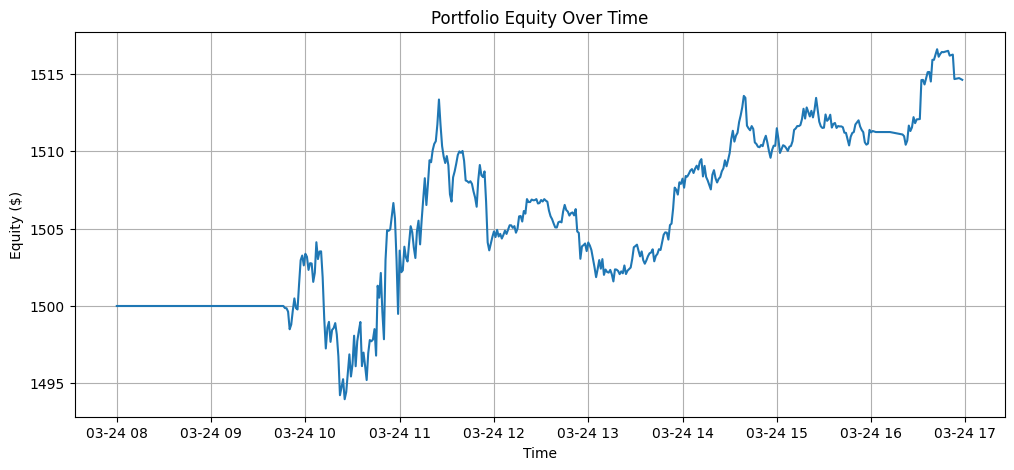

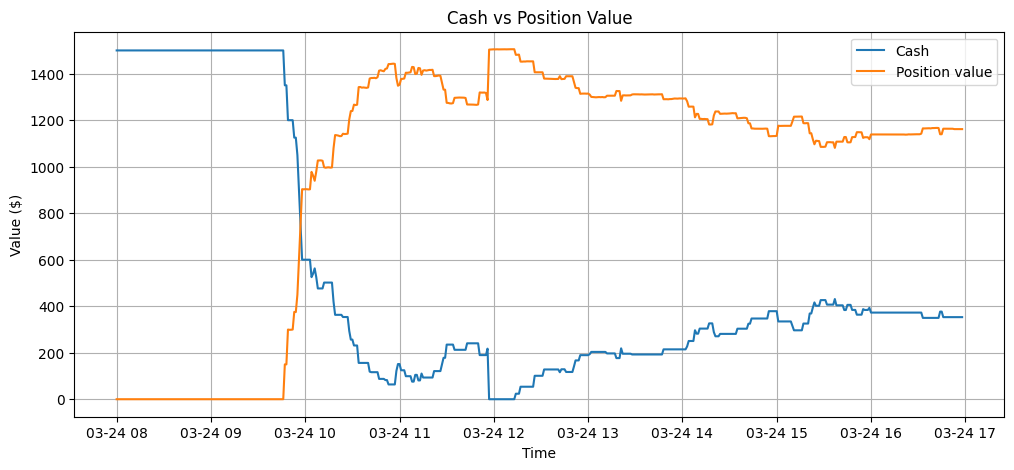

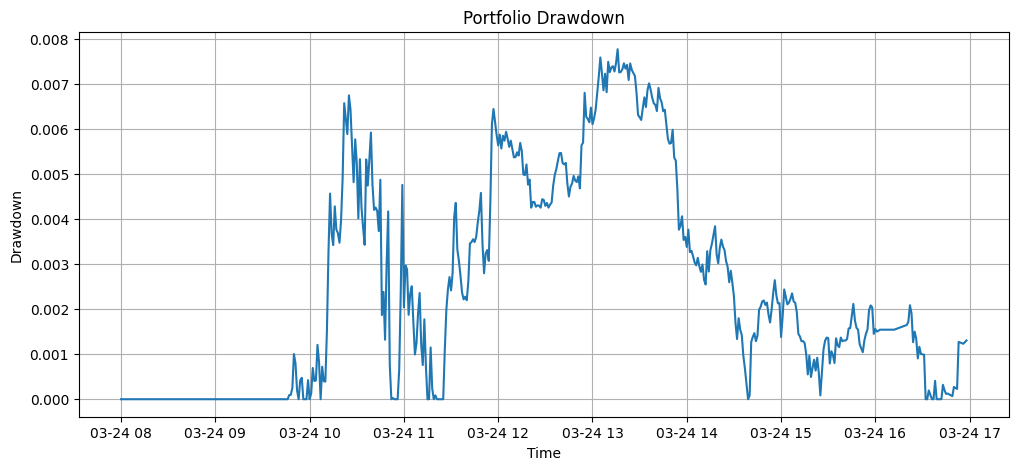

In [2]:
# ============================================================
# ETF-THEME-FIRST DAILY-UNIVERSE BUY / SELL / RISK BACKTEST CELL
# Uses output from the first cell:
#   - raw_bars_df
#   - stationary_tables_by_ticker
#   - TICKERS
#   - daily_selected_by_date
#   - daily_universe_df
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# 1. BACKTEST SETTINGS
# ============================================================

STARTING_CASH = 1500.0

# Buy only uses a fraction of that ticker's daily cash bucket.
# Each selected ticker gets an equal bucket at the start of its trading day.
BUY_FRACTION_OF_BUCKET = 0.50

MIN_TRADE_DOLLARS = 2.00

# Profit sell rule:
# sell_fraction = unrealised_return * SELL_FRACTION_MULTIPLIER
# Example:
# +1% gain -> 10% sell
# +3% gain -> 30% sell
# +5% gain -> 50% sell
SELL_FRACTION_MULTIPLIER = 10.0

MIN_PROFIT_SELL_FRACTION = 0.10
MAX_PROFIT_SELL_FRACTION = 1.00

# Portfolio-level risk control.
ENABLE_PORTFOLIO_KILL_SWITCH = True
PORTFOLIO_KILL_SWITCH = 0.03   # 3% hard kill switch from peak equity

# Adaptive inverse ETF weighting controller.
# Danger signal:
#   portfolio drawdown from peak >= 0.5%
#   smoothed portfolio return is negative
#   smoothed return acceleration <= -0.0015
#
# Weighting rule:
#   If danger appears while inverse ETF is NOT majority: inverse target += 20%.
#   If danger appears while inverse ETF IS majority: inverse target -= 20%.
#   Max inverse ETF target = 80%.
#
# Funding rule:
#   Inverse ETF buys use cash first, then normal-stock cash buckets, then sell
#   normal stock positions evenly if needed.
#   Inverse ETF sells distribute proceeds evenly back to today's normal-stock
#   cash buckets so normal stocks can buy again on later valid minima.
ENABLE_INVERSE_ETF_MODE = True

MODE2_DRAWDOWN_TRIGGER = 0.005          # 0.5% drawdown from peak
PORTFOLIO_DERIVATIVE_INTERVAL = "15min"
PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW = 3
PORTFOLIO_ACCEL_RETURN_THRESHOLD = -0.0015

INVERSE_WEIGHT_STEP = 0.20
MAX_INVERSE_WEIGHT = 0.80
INVERSE_MAJORITY_WEIGHT = 0.50

# Theme-failure guard.
# Disabled in the fast no-ETF-candle version because ETF intraday candles are not downloaded.
# Sells and portfolio-level risk controls still work.
ENABLE_THEME_FAILURE_GUARD = False
THEME_FAIL_DROP_FROM_OPEN = 0.005
THEME_FAIL_USE_BUFFER_LOW = False

# Theme-rotation rescue also needs ETF intraday candles, so it is disabled here.
ENABLE_THEME_ROTATION_ON_FAILURE = False
MAX_THEME_SWITCHES_PER_DAY = 0

# This is recommended for the daily-changing universe.
# It keeps the bot intraday-only and resets buckets each day.
FORCE_CLOSE_EACH_DAY = True

# Trading cost assumptions.
FEE_RATE = 0.0
SLIPPAGE_RATE = 0.0005   # 0.05% assumed slippage

# 1-minute data reliability buy guard.
# Even after the daily selector prefers reliable 1-minute tickers, this blocks a
# buy if the specific ticker does not have a recent bar at the signal time.
REQUIRE_RECENT_BAR_FOR_BUYS = True
MAX_RECENT_BAR_AGE_MINUTES = globals().get("MAX_RECENT_BAR_AGE_MINUTES", 2)


# ============================================================
# 2. SAFETY CHECKS
# ============================================================

required_objects = [
    "raw_bars_df",
    "stationary_tables_by_ticker",
    "TICKERS",
    "daily_selected_by_date",
    "daily_universe_df",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(
            f"Missing {obj_name}. Run the updated stationary-point + daily-universe cell first."
        )

if raw_bars_df.empty:
    raise ValueError("raw_bars_df is empty. Run the Alpaca data cell again.")

if len(stationary_tables_by_ticker) == 0:
    raise ValueError("stationary_tables_by_ticker is empty.")

if daily_universe_df.empty:
    raise ValueError("daily_universe_df is empty. Daily selection produced no stocks.")


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def calculate_profit_sell_fraction(unrealised_return):
    """
    unrealised_return:
        0.03 = +3%
        1.00 = +100%
        -0.02 = -2%

    Profit-taking only happens at confirmed local maximums.
    """

    if unrealised_return <= 0:
        return 0.0

    if unrealised_return >= 1.00:
        return 1.00

    sell_fraction = unrealised_return * SELL_FRACTION_MULTIPLIER

    sell_fraction = max(sell_fraction, MIN_PROFIT_SELL_FRACTION)
    sell_fraction = min(sell_fraction, MAX_PROFIT_SELL_FRACTION)

    return sell_fraction


def get_current_price(ticker, current_time, bars_by_ticker, last_known_prices):
    """
    Gets current close price for ticker at current_time.
    If exact row is unavailable, use last known price.
    """

    ticker_bars = bars_by_ticker.get(ticker)

    if ticker_bars is None or ticker_bars.empty:
        return last_known_prices.get(ticker, np.nan)

    if current_time in ticker_bars.index:
        price = ticker_bars.loc[current_time, "Close"]

        # If duplicate timestamps somehow occur, take the last one.
        if isinstance(price, pd.Series):
            price = price.iloc[-1]

        last_known_prices[ticker] = price
        return price

    return last_known_prices.get(ticker, np.nan)


def has_recent_bar(ticker, current_time, bars_by_ticker, max_age_minutes=2):
    """
    Returns True only if ticker has a real bar at or shortly before current_time.

    This prevents buying from a stale last_known_price when the 1-minute stream has
    missing bars. Sells still use get_current_price so risk exits can occur even
    if the exact bar is unavailable.
    """
    ticker_bars = bars_by_ticker.get(ticker)

    if ticker_bars is None or ticker_bars.empty:
        return False

    available_times = ticker_bars.index[ticker_bars.index <= current_time]

    if len(available_times) == 0:
        return False

    last_bar_time = available_times[-1]

    age_minutes = (current_time - last_bar_time).total_seconds() / 60.0

    return age_minutes <= max_age_minutes



def get_selected_theme_by_date(etf_theme_scores_df=None, daily_universe_df=None):
    """
    Returns a dict keyed by date with the ETF/theme selected for that day.

    Expected format:
        {
            date: {
                "theme": "Semiconductors",
                "theme_etf": "SMH",
                "etf_growth_return": 0.25,
            }
        }
    """
    selected_theme_by_date = {}

    if etf_theme_scores_df is not None and not etf_theme_scores_df.empty:
        theme_df = etf_theme_scores_df.copy()

        if "is_selected_theme" in theme_df.columns:
            theme_df = theme_df[theme_df["is_selected_theme"]].copy()

        needed = {"date", "theme", "theme_etf"}
        if needed.issubset(theme_df.columns):
            for _, row in theme_df.iterrows():
                selected_theme_by_date[row["date"]] = {
                    "theme": row.get("theme", "Unknown"),
                    "theme_etf": row.get("theme_etf", None),
                    "etf_growth_return": row.get("etf_growth_return", np.nan),
                }

    # Fallback: use the first selected stock row for each date if the daily universe
    # has theme columns. This keeps the backtest cell usable even if the theme table
    # was not retained in memory for some reason.
    if (not selected_theme_by_date) and daily_universe_df is not None and not daily_universe_df.empty:
        if {"date", "selected_theme", "selected_theme_etf"}.issubset(daily_universe_df.columns):
            for current_date, day_df in daily_universe_df.groupby("date"):
                row = day_df.iloc[0]
                selected_theme_by_date[current_date] = {
                    "theme": row.get("selected_theme", "Unknown"),
                    "theme_etf": row.get("selected_theme_etf", None),
                    "etf_growth_return": row.get("selected_etf_growth", np.nan),
                }

    return selected_theme_by_date


def get_ranked_theme_candidates_by_date(etf_theme_scores_df=None, daily_universe_df=None):
    """
    Returns a dict keyed by date. Each value is a ranked list of ETF themes:
        {
            date: [
                {"theme": ..., "theme_etf": ..., "etf_growth_return": ..., "etf_growth_rank": ...},
                ...
            ]
        }

    Used for intraday theme rotation. The bot starts with rank 1. If rank 1 fails,
    it can try rank 2, then stop if the backup also fails.
    """
    ranked_by_date = {}

    if etf_theme_scores_df is not None and not etf_theme_scores_df.empty:
        needed = {"date", "theme", "theme_etf"}
        if needed.issubset(etf_theme_scores_df.columns):
            theme_df = etf_theme_scores_df.copy()

            sort_cols = ["date"]
            ascending = [True]

            if "etf_growth_rank" in theme_df.columns:
                sort_cols.append("etf_growth_rank")
                ascending.append(True)
            elif "etf_growth_return" in theme_df.columns:
                sort_cols.append("etf_growth_return")
                ascending.append(False)

            theme_df = theme_df.sort_values(sort_cols, ascending=ascending)

            for current_date, day_df in theme_df.groupby("date"):
                candidates = []
                for _, row in day_df.iterrows():
                    candidates.append({
                        "theme": row.get("theme", "Unknown"),
                        "theme_etf": row.get("theme_etf", None),
                        "etf_growth_return": row.get("etf_growth_return", np.nan),
                        "etf_growth_rank": row.get("etf_growth_rank", np.nan),
                    })
                ranked_by_date[current_date] = candidates

    # Fallback: only the originally selected theme is known.
    if (not ranked_by_date) and daily_universe_df is not None and not daily_universe_df.empty:
        if {"date", "selected_theme", "selected_theme_etf"}.issubset(daily_universe_df.columns):
            for current_date, day_df in daily_universe_df.groupby("date"):
                row = day_df.iloc[0]
                ranked_by_date[current_date] = [{
                    "theme": row.get("selected_theme", "Unknown"),
                    "theme_etf": row.get("selected_theme_etf", None),
                    "etf_growth_return": row.get("selected_theme_growth", np.nan),
                    "etf_growth_rank": 1,
                }]

    return ranked_by_date


def build_selected_tickers_for_theme(current_date, theme, all_stock_scores_df, max_stocks=None):
    """
    Rebuilds the selected stock list for a replacement ETF theme using the already
    computed all_stock_scores_df. This avoids redownloading data during the backtest.
    """
    if max_stocks is None:
        max_stocks = globals().get("MAX_STOCKS_PER_DAY", 5)

    if all_stock_scores_df is None or all_stock_scores_df.empty:
        return []

    day_stock_df = all_stock_scores_df[all_stock_scores_df["date"] == current_date].copy()
    if day_stock_df.empty:
        return []

    # Recalculate theme_match for the proposed backup theme, not the original theme.
    if "stock_matches_etf_theme" in globals():
        day_stock_df["rotation_theme_match"] = day_stock_df.apply(
            lambda row: stock_matches_etf_theme(row, theme),
            axis=1
        )
    else:
        # Safe fallback: if the matcher is unavailable, allow broad selection by final score.
        day_stock_df["rotation_theme_match"] = True

    day_stock_df = day_stock_df.sort_values("final_score", ascending=False)

    if globals().get("PRIORITISE_STRONGEST_ETF_THEME", True):
        theme_pool = day_stock_df[day_stock_df["rotation_theme_match"]].sort_values("final_score", ascending=False)
        non_theme_pool = day_stock_df[~day_stock_df["rotation_theme_match"]].sort_values("final_score", ascending=False)
        candidate_order_df = pd.concat([theme_pool, non_theme_pool], ignore_index=True)
    else:
        candidate_order_df = day_stock_df

    selected_for_day = []
    selected_tickers = set()
    sector_counts = {}
    max_per_sector = globals().get("MAX_STOCKS_PER_SECTOR", max_stocks)

    for _, row in candidate_order_df.iterrows():
        ticker = row.get("ticker")
        sector = row.get("sector", "Unknown")

        if ticker in selected_tickers:
            continue

        if sector_counts.get(sector, 0) >= max_per_sector:
            continue

        selected_for_day.append(ticker)
        selected_tickers.add(ticker)
        sector_counts[sector] = sector_counts.get(sector, 0) + 1

        if len(selected_for_day) >= max_stocks:
            break

    # If the sector cap leaves too few stocks, fill from the next best names.
    if len(selected_for_day) < max_stocks:
        for _, row in candidate_order_df.iterrows():
            ticker = row.get("ticker")

            if ticker in selected_tickers:
                continue

            selected_for_day.append(ticker)
            selected_tickers.add(ticker)

            if len(selected_for_day) >= max_stocks:
                break

    return selected_for_day


def find_healthy_backup_theme(
    current_date,
    current_time,
    current_theme_etf,
    failed_theme_etfs_today,
    ranked_theme_candidates_by_date,
    theme_bars_by_etf,
    all_stock_scores_df,
):
    """
    Finds the next-best ETF theme that has not already failed today and is still
    healthy at the current timestamp.
    """
    candidates = ranked_theme_candidates_by_date.get(current_date, [])

    for candidate in candidates:
        theme = candidate.get("theme", "Unknown")
        theme_etf = candidate.get("theme_etf")

        if not theme_etf:
            continue

        if theme_etf == current_theme_etf:
            continue

        if theme_etf in failed_theme_etfs_today:
            continue

        selected_tickers = build_selected_tickers_for_theme(
            current_date=current_date,
            theme=theme,
            all_stock_scores_df=all_stock_scores_df,
            max_stocks=globals().get("MAX_STOCKS_PER_DAY", 5),
        )

        if len(selected_tickers) == 0:
            continue

        candidate_theme_by_date = {
            current_date: {
                "theme": theme,
                "theme_etf": theme_etf,
                "etf_growth_return": candidate.get("etf_growth_return", np.nan),
            }
        }

        candidate_state = check_theme_failure(
            current_date=current_date,
            current_time=current_time,
            selected_theme_by_date=candidate_theme_by_date,
            theme_bars_by_etf=theme_bars_by_etf,
            buffer_minutes=MARKET_OPEN_BUFFER_MINUTES,
            drop_from_open_threshold=THEME_FAIL_DROP_FROM_OPEN,
            use_buffer_low=THEME_FAIL_USE_BUFFER_LOW,
        )

        if not candidate_state.get("theme_failed", False):
            return {
                "theme_info": candidate_theme_by_date[current_date],
                "selected_tickers": selected_tickers,
                "health_state": candidate_state,
            }

        failed_theme_etfs_today.add(theme_etf)

    return None


def build_theme_bars_by_etf(raw_bars_df):
    """
    Builds a dict of minute bars for the hard-coded ETF themes from raw_bars_df.
    The first cell downloads these ETFs along with the stock universe.
    """
    if "POPULAR_ETFS_FOR_UNIVERSE" not in globals():
        return {}

    theme_etfs = set(POPULAR_ETFS_FOR_UNIVERSE.values())
    theme_bars_by_etf = {}

    for etf in sorted(theme_etfs):
        etf_df = raw_bars_df[raw_bars_df["ticker"] == etf].copy()
        if etf_df.empty:
            continue

        etf_df = etf_df.set_index("time").sort_index()
        theme_bars_by_etf[etf] = etf_df

    return theme_bars_by_etf


def check_theme_failure(
    current_date,
    current_time,
    selected_theme_by_date,
    theme_bars_by_etf,
    buffer_minutes=15,
    drop_from_open_threshold=0.005,
    use_buffer_low=True,
):
    """
    Theme-failure guard.

    Returns a dict:
        {
            "theme_failed": bool,
            "reason": str,
            "theme": str,
            "theme_etf": str,
            "theme_price": float,
            "theme_open": float,
            "theme_return_from_open": float,
            "theme_buffer_low": float,
        }

    Rule used in this first version:
        After the normal market-open buffer, the selected theme fails if:
            1) ETF is down more than drop_from_open_threshold from its open, OR
            2) ETF breaks below its opening-buffer low.

    This only blocks new buys. It does not force-sell by itself.
    """
    empty_state = {
        "theme_failed": False,
        "reason": "no_theme_failure",
        "theme": None,
        "theme_etf": None,
        "theme_price": np.nan,
        "theme_open": np.nan,
        "theme_return_from_open": np.nan,
        "theme_buffer_low": np.nan,
    }

    theme_info = selected_theme_by_date.get(current_date)
    if not theme_info:
        empty_state["reason"] = "no_selected_theme_for_date"
        return empty_state

    theme = theme_info.get("theme", "Unknown")
    theme_etf = theme_info.get("theme_etf")

    empty_state["theme"] = theme
    empty_state["theme_etf"] = theme_etf

    if not theme_etf or theme_etf not in theme_bars_by_etf:
        empty_state["reason"] = "no_theme_etf_bars"
        return empty_state

    market_open = datetime.combine(current_date, time(9, 30), tzinfo=NY_TZ)
    buffer_end = market_open + timedelta(minutes=buffer_minutes)

    # There are no buys before the buffer anyway, so do not fail the theme before then.
    if current_time < buffer_end:
        empty_state["reason"] = "before_open_buffer_end"
        return empty_state

    theme_bars_today = theme_bars_by_etf[theme_etf]
    theme_bars_today = theme_bars_today[theme_bars_today.index.date == current_date].copy()

    if theme_bars_today.empty:
        empty_state["reason"] = "no_theme_bars_today"
        return empty_state

    bars_so_far = theme_bars_today[theme_bars_today.index <= current_time].copy()
    if bars_so_far.empty:
        empty_state["reason"] = "no_theme_bars_so_far"
        return empty_state

    theme_open = float(theme_bars_today.iloc[0]["Open"])
    theme_price = float(bars_so_far.iloc[-1]["Close"])

    if theme_open <= 0 or not np.isfinite(theme_open) or not np.isfinite(theme_price):
        empty_state["reason"] = "bad_theme_price"
        return empty_state

    theme_return_from_open = (theme_price - theme_open) / theme_open

    buffer_bars = theme_bars_today[
        (theme_bars_today.index >= market_open)
        & (theme_bars_today.index <= buffer_end)
    ]

    theme_buffer_low = np.nan
    broke_buffer_low = False

    if use_buffer_low and not buffer_bars.empty:
        theme_buffer_low = float(buffer_bars["Low"].min())
        broke_buffer_low = theme_price < theme_buffer_low

    failed_by_open_drop = theme_return_from_open <= -drop_from_open_threshold

    failed = failed_by_open_drop or broke_buffer_low

    if failed_by_open_drop and broke_buffer_low:
        reason = "theme_drop_from_open_and_broke_buffer_low"
    elif failed_by_open_drop:
        reason = "theme_drop_from_open"
    elif broke_buffer_low:
        reason = "theme_broke_opening_buffer_low"
    else:
        reason = "no_theme_failure"

    return {
        "theme_failed": bool(failed),
        "reason": reason,
        "theme": theme,
        "theme_etf": theme_etf,
        "theme_price": theme_price,
        "theme_open": theme_open,
        "theme_return_from_open": theme_return_from_open,
        "theme_buffer_low": theme_buffer_low,
    }

def calculate_portfolio_value(cash_pool, stock_cash, positions, bars_by_ticker, current_time, last_known_prices):
    """
    Portfolio equity = unallocated cash pool + daily ticker cash buckets + current position value.
    """

    bucket_cash = sum(stock_cash.values())
    position_value = 0.0

    per_ticker_values = {}

    for ticker in TICKERS:
        price = get_current_price(
            ticker=ticker,
            current_time=current_time,
            bars_by_ticker=bars_by_ticker,
            last_known_prices=last_known_prices
        )

        pos = positions.get(ticker)

        if pos is None:
            ticker_position_value = 0.0
        else:
            ticker_position_value = pos["quantity"] * price if not pd.isna(price) else 0.0

        ticker_total_value = stock_cash.get(ticker, 0.0) + ticker_position_value

        per_ticker_values[ticker] = {
            "cash_bucket": stock_cash.get(ticker, 0.0),
            "position_value": ticker_position_value,
            "total_value": ticker_total_value,
            "price": price
        }

        position_value += ticker_position_value

    total_cash = cash_pool + bucket_cash
    equity = total_cash + position_value

    return equity, total_cash, position_value, per_ticker_values


def get_position_market_value(ticker, positions, bars_by_ticker, current_time, last_known_prices):
    """Current market value of one ticker position before slippage."""
    pos = positions.get(ticker)
    if pos is None:
        return 0.0

    price = get_current_price(
        ticker=ticker,
        current_time=current_time,
        bars_by_ticker=bars_by_ticker,
        last_known_prices=last_known_prices,
    )

    if pd.isna(price):
        return 0.0

    return pos["quantity"] * price


def sell_position_value_to_cash_pool(
    ticker,
    target_sell_value,
    current_time,
    reason,
    cash_pool,
    positions,
    bars_by_ticker,
    last_known_prices,
    trade_log,
):
    """
    Sells approximately target_sell_value dollars of one position.
    Proceeds go to the shared cash_pool. Used for adaptive inverse ETF rebalancing.
    """
    if target_sell_value <= 0:
        return cash_pool, 0.0

    pos = positions.get(ticker)
    if pos is None:
        return cash_pool, 0.0

    current_price = get_current_price(
        ticker=ticker,
        current_time=current_time,
        bars_by_ticker=bars_by_ticker,
        last_known_prices=last_known_prices,
    )

    if pd.isna(current_price) or current_price <= 0:
        return cash_pool, 0.0

    exit_price = current_price * (1 - SLIPPAGE_RATE)
    current_value_at_exit = pos["quantity"] * exit_price
    gross_value = min(target_sell_value, current_value_at_exit)

    if gross_value < MIN_TRADE_DOLLARS:
        return cash_pool, 0.0

    quantity_to_sell = gross_value / exit_price
    quantity_to_sell = min(quantity_to_sell, pos["quantity"])

    gross_value = quantity_to_sell * exit_price
    fee = gross_value * FEE_RATE
    net_value = gross_value - fee

    old_quantity = pos["quantity"]
    old_cost_basis = pos["cost_basis"]
    fraction_sold = quantity_to_sell / old_quantity if old_quantity > 0 else 1.0
    cost_basis_sold = old_cost_basis * fraction_sold
    realised_pnl = net_value - cost_basis_sold

    remaining_quantity = old_quantity - quantity_to_sell
    remaining_cost_basis = old_cost_basis - cost_basis_sold

    cash_pool += net_value

    if remaining_quantity <= 1e-12:
        positions[ticker] = None
    else:
        pos["quantity"] = remaining_quantity
        pos["cost_basis"] = remaining_cost_basis
        pos["avg_entry_price"] = remaining_cost_basis / remaining_quantity
        positions[ticker] = pos

    trade_log.append({
        "ticker": ticker,
        "action": "SELL",
        "reason": reason,
        "time": current_time,
        "price": exit_price,
        "quantity": quantity_to_sell,
        "gross_value": gross_value,
        "fee": fee,
        "net_value": net_value,
        "cost_basis_sold": cost_basis_sold,
        "realised_pnl": realised_pnl,
        "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,
        "cash_pool_after": cash_pool,
    })

    return cash_pool, net_value


def buy_position_from_cash_pool(
    ticker,
    buy_value,
    current_time,
    reason,
    cash_pool,
    positions,
    bars_by_ticker,
    last_known_prices,
    trade_log,
):
    """Buys a ticker using shared cash_pool."""
    if buy_value <= 0 or cash_pool < MIN_TRADE_DOLLARS:
        return cash_pool, 0.0

    current_price = get_current_price(
        ticker=ticker,
        current_time=current_time,
        bars_by_ticker=bars_by_ticker,
        last_known_prices=last_known_prices,
    )

    if pd.isna(current_price) or current_price <= 0:
        return cash_pool, 0.0

    entry_price = current_price * (1 + SLIPPAGE_RATE)
    buy_value = min(buy_value, cash_pool)

    quantity_to_buy = buy_value / entry_price
    gross_cost = quantity_to_buy * entry_price
    fee = gross_cost * FEE_RATE
    total_cost = gross_cost + fee

    if total_cost > cash_pool:
        total_cost = cash_pool
        gross_cost = total_cost / (1 + FEE_RATE)
        fee = total_cost - gross_cost
        quantity_to_buy = gross_cost / entry_price

    if total_cost < MIN_TRADE_DOLLARS or quantity_to_buy <= 0:
        return cash_pool, 0.0

    cash_pool -= total_cost

    existing_pos = positions.get(ticker)

    if existing_pos is None:
        positions[ticker] = {
            "quantity": quantity_to_buy,
            "cost_basis": total_cost,
            "avg_entry_price": total_cost / quantity_to_buy,
            "first_entry_time": current_time,
            "last_entry_time": current_time,
        }
    else:
        new_quantity = existing_pos["quantity"] + quantity_to_buy
        new_cost_basis = existing_pos["cost_basis"] + total_cost
        existing_pos["quantity"] = new_quantity
        existing_pos["cost_basis"] = new_cost_basis
        existing_pos["avg_entry_price"] = new_cost_basis / new_quantity
        existing_pos["last_entry_time"] = current_time
        positions[ticker] = existing_pos

    trade_log.append({
        "ticker": ticker,
        "action": "BUY",
        "reason": reason,
        "time": current_time,
        "price": entry_price,
        "quantity": quantity_to_buy,
        "gross_value": gross_cost,
        "fee": fee,
        "net_value": total_cost,
        "cash_pool_after": cash_pool,
    })

    return cash_pool, total_cost


def take_cash_evenly_from_stock_buckets(amount_needed, stock_cash, selected_today, exclude_tickers=None):
    """
    Takes available bucket cash evenly from selected normal-stock buckets.
    Returns amount actually taken.
    """
    if amount_needed <= 0:
        return 0.0

    exclude_tickers = set(exclude_tickers or [])
    eligible = [
        t for t in selected_today
        if t in stock_cash and t not in exclude_tickers and stock_cash.get(t, 0.0) > 0
    ]

    total_taken = 0.0
    remaining = amount_needed

    while remaining > 1e-9 and eligible:
        take_each = remaining / len(eligible)
        next_eligible = []

        for t in eligible:
            available = stock_cash.get(t, 0.0)
            take = min(available, take_each)
            stock_cash[t] = available - take
            total_taken += take
            remaining -= take

            if stock_cash[t] > 1e-9:
                next_eligible.append(t)

        if len(next_eligible) == len(eligible):
            break

        eligible = next_eligible

    return total_taken


def sell_normal_positions_evenly_to_cash_pool(
    amount_needed,
    selected_today,
    inverse_symbol_today,
    current_time,
    cash_pool,
    positions,
    bars_by_ticker,
    last_known_prices,
    trade_log,
):
    """
    Raises cash by selling normal stock positions evenly by dollar value.
    It does not sell the inverse ETF.
    """
    if amount_needed <= 0:
        return cash_pool, 0.0

    eligible = [
        t for t in selected_today
        if t != inverse_symbol_today
        and positions.get(t) is not None
        and get_position_market_value(t, positions, bars_by_ticker, current_time, last_known_prices) > 0
    ]

    total_raised = 0.0
    remaining = amount_needed

    while remaining > MIN_TRADE_DOLLARS and eligible:
        sell_each = remaining / len(eligible)
        next_eligible = []

        for t in eligible:
            before = cash_pool
            cash_pool, raised = sell_position_value_to_cash_pool(
                ticker=t,
                target_sell_value=sell_each,
                current_time=current_time,
                reason="adaptive_inverse_rebalance_sell_normal_evenly",
                cash_pool=cash_pool,
                positions=positions,
                bars_by_ticker=bars_by_ticker,
                last_known_prices=last_known_prices,
                trade_log=trade_log,
            )
            total_raised += raised
            remaining = amount_needed - total_raised

            if positions.get(t) is not None and raised > 0:
                next_eligible.append(t)

        if not next_eligible or len(next_eligible) == len(eligible):
            break

        eligible = next_eligible

    return cash_pool, total_raised


def distribute_cash_to_normal_buckets(amount, cash_pool, stock_cash, selected_today, inverse_symbol_today):
    """
    Moves amount from cash_pool into selected normal-stock cash buckets evenly.
    Used after trimming inverse ETF exposure.
    """
    if amount <= 0 or cash_pool <= 0:
        return cash_pool, 0.0

    recipients = [
        t for t in selected_today
        if t in stock_cash and t != inverse_symbol_today
    ]

    amount = min(amount, cash_pool)

    if not recipients:
        return cash_pool, 0.0

    per_ticker = amount / len(recipients)

    for t in recipients:
        stock_cash[t] = stock_cash.get(t, 0.0) + per_ticker

    cash_pool -= amount

    return cash_pool, amount


def compute_portfolio_derivative_signal(
    equity_curve,
    current_time,
    interval=PORTFOLIO_DERIVATIVE_INTERVAL,
    smooth_window=PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW,
):
    """
    Computes smoothed portfolio slope_return and accel_return from equity_curve.
    Returns enough info for the adaptive inverse ETF danger signal.
    """
    if len(equity_curve) < smooth_window + 3:
        return {
            "has_signal": False,
            "slope_return": np.nan,
            "accel_return": np.nan,
            "derivative_interval_time": None,
        }

    temp = pd.DataFrame(equity_curve)[["time", "equity"]].copy()
    temp["time"] = pd.to_datetime(temp["time"])
    temp["equity"] = pd.to_numeric(temp["equity"], errors="coerce")
    temp = temp.dropna(subset=["time", "equity"]).sort_values("time").set_index("time")

    if temp.empty:
        return {
            "has_signal": False,
            "slope_return": np.nan,
            "accel_return": np.nan,
            "derivative_interval_time": None,
        }

    interval_df = temp.resample(interval).last().dropna()

    if len(interval_df) < smooth_window + 3:
        return {
            "has_signal": False,
            "slope_return": np.nan,
            "accel_return": np.nan,
            "derivative_interval_time": None,
        }

    interval_df["equity_smooth"] = (
        interval_df["equity"]
        .rolling(window=smooth_window, min_periods=smooth_window)
        .mean()
    )
    interval_df["slope_return"] = interval_df["equity_smooth"].pct_change()
    interval_df["accel_return"] = interval_df["slope_return"].diff()

    last_row = interval_df.dropna(subset=["slope_return", "accel_return"]).tail(1)

    if last_row.empty:
        return {
            "has_signal": False,
            "slope_return": np.nan,
            "accel_return": np.nan,
            "derivative_interval_time": None,
        }

    return {
        "has_signal": True,
        "slope_return": float(last_row["slope_return"].iloc[0]),
        "accel_return": float(last_row["accel_return"].iloc[0]),
        "derivative_interval_time": last_row.index[0],
    }


def rebalance_inverse_etf_to_target(
    target_inverse_weight,
    equity,
    current_time,
    cash_pool,
    stock_cash,
    positions,
    selected_today,
    inverse_symbol_today,
    bars_by_ticker,
    last_known_prices,
    trade_log,
):
    """
    Rebalances inverse ETF position to target weight of current portfolio equity.

    If inverse ETF needs more money:
        cash_pool -> selected stock_cash buckets -> sell normal positions evenly.

    If inverse ETF needs to be reduced:
        sell inverse ETF and distribute proceeds evenly into selected normal-stock buckets.
    """
    if inverse_symbol_today is None or inverse_symbol_today not in TICKERS:
        return cash_pool, 0.0, 0.0, "no_inverse_symbol"

    inverse_price = get_current_price(
        ticker=inverse_symbol_today,
        current_time=current_time,
        bars_by_ticker=bars_by_ticker,
        last_known_prices=last_known_prices,
    )

    if pd.isna(inverse_price) or inverse_price <= 0:
        return cash_pool, 0.0, 0.0, "no_inverse_price"

    target_inverse_value = max(0.0, equity * target_inverse_weight)
    current_inverse_value = get_position_market_value(
        inverse_symbol_today,
        positions,
        bars_by_ticker,
        current_time,
        last_known_prices,
    )

    value_diff = target_inverse_value - current_inverse_value

    if abs(value_diff) < MIN_TRADE_DOLLARS:
        return cash_pool, current_inverse_value, target_inverse_value, "already_close_to_target"

    if value_diff > 0:
        needed = value_diff

        # 1. Use shared cash first.
        cash_available = min(cash_pool, needed)
        buy_cash = cash_available
        cash_pool -= cash_available
        needed -= cash_available

        # Temporarily keep funding cash in cash_pool for the buy helper.
        cash_pool += buy_cash

        # 2. If needed, take normal-stock bucket cash evenly.
        if needed > MIN_TRADE_DOLLARS:
            bucket_taken = take_cash_evenly_from_stock_buckets(
                amount_needed=needed,
                stock_cash=stock_cash,
                selected_today=selected_today,
                exclude_tickers=[inverse_symbol_today],
            )
            cash_pool += bucket_taken
            needed -= bucket_taken

        # 3. If still needed, sell normal positions evenly.
        if needed > MIN_TRADE_DOLLARS:
            cash_pool, raised = sell_normal_positions_evenly_to_cash_pool(
                amount_needed=needed,
                selected_today=selected_today,
                inverse_symbol_today=inverse_symbol_today,
                current_time=current_time,
                cash_pool=cash_pool,
                positions=positions,
                bars_by_ticker=bars_by_ticker,
                last_known_prices=last_known_prices,
                trade_log=trade_log,
            )

        # 4. Buy inverse ETF with whatever cash was made available, capped at value_diff.
        buy_value = min(value_diff, cash_pool)
        cash_pool, traded_value = buy_position_from_cash_pool(
            ticker=inverse_symbol_today,
            buy_value=buy_value,
            current_time=current_time,
            reason="adaptive_inverse_rebalance_buy_to_target",
            cash_pool=cash_pool,
            positions=positions,
            bars_by_ticker=bars_by_ticker,
            last_known_prices=last_known_prices,
            trade_log=trade_log,
        )

        return cash_pool, current_inverse_value, target_inverse_value, "bought_inverse"

    else:
        sell_value = abs(value_diff)

        cash_before = cash_pool
        cash_pool, sold_value = sell_position_value_to_cash_pool(
            ticker=inverse_symbol_today,
            target_sell_value=sell_value,
            current_time=current_time,
            reason="adaptive_inverse_rebalance_sell_to_target",
            cash_pool=cash_pool,
            positions=positions,
            bars_by_ticker=bars_by_ticker,
            last_known_prices=last_known_prices,
            trade_log=trade_log,
        )

        proceeds = cash_pool - cash_before

        # Move the inverse-sale proceeds into normal-stock cash buckets.
        cash_pool, distributed = distribute_cash_to_normal_buckets(
            amount=proceeds,
            cash_pool=cash_pool,
            stock_cash=stock_cash,
            selected_today=selected_today,
            inverse_symbol_today=inverse_symbol_today,
        )

        return cash_pool, current_inverse_value, target_inverse_value, "sold_inverse"



def close_position(ticker, current_time, reason, cash_pool, stock_cash, positions, bars_by_ticker, last_known_prices, trade_log):
    """
    Closes one ticker position and returns proceeds to that ticker's cash bucket.
    The cash bucket will later be swept back to the global cash pool at end of day.
    """
    pos = positions.get(ticker)

    if pos is None:
        return cash_pool

    current_price = get_current_price(
        ticker=ticker,
        current_time=current_time,
        bars_by_ticker=bars_by_ticker,
        last_known_prices=last_known_prices
    )

    if pd.isna(current_price):
        return cash_pool

    exit_price = current_price * (1 - SLIPPAGE_RATE)

    quantity_to_sell = pos["quantity"]
    gross_value = quantity_to_sell * exit_price
    fee = gross_value * FEE_RATE
    net_value = gross_value - fee

    cost_basis_sold = pos["cost_basis"]
    realised_pnl = net_value - cost_basis_sold

    stock_cash[ticker] = stock_cash.get(ticker, 0.0) + net_value

    trade_log.append({
        "ticker": ticker,
        "action": "SELL",
        "reason": reason,
        "time": current_time,
        "price": exit_price,
        "quantity": quantity_to_sell,
        "gross_value": gross_value,
        "fee": fee,
        "net_value": net_value,
        "cost_basis_sold": cost_basis_sold,
        "realised_pnl": realised_pnl,
        "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,
        "stock_cash_after": stock_cash[ticker],
        "cash_pool_after": cash_pool,
    })

    positions[ticker] = None

    return cash_pool


def sweep_buckets_to_cash_pool(cash_pool, stock_cash):
    """
    Moves all ticker bucket cash back into the shared cash pool.
    Used at the end of each trading day.
    """
    cash_pool += sum(stock_cash.values())

    for ticker in stock_cash:
        stock_cash[ticker] = 0.0

    return cash_pool


def allocate_daily_buckets(cash_pool, stock_cash, selected_today):
    """
    Allocates the current cash pool equally across today's selected stocks.

    Important behaviour:
        Every new trading day starts from one shared pool.
        If account equity/cash is $1,700 and 5 stocks are selected,
        every selected stock starts with a $340 bucket, regardless of
        which stock made yesterday's profit.
    """
    for ticker in stock_cash:
        stock_cash[ticker] = 0.0

    selected_today = [ticker for ticker in selected_today if ticker in stock_cash]

    if len(selected_today) == 0 or cash_pool <= 0:
        return cash_pool

    per_ticker_cash = cash_pool / len(selected_today)

    for ticker in selected_today:
        stock_cash[ticker] = per_ticker_cash

    cash_pool = 0.0

    return cash_pool


# ============================================================
# 4. PREPARE BAR DATA
# ============================================================

bars_df = raw_bars_df[raw_bars_df["ticker"].isin(TICKERS)].copy()

# Single-day support:
# the first cell may download extra lookback data, but the backtest should only
# loop through the actual requested trading window.
BACKTEST_START_TIME = globals().get("BACKTEST_START_TIME", bars_df["time"].min())
BACKTEST_END_TIME = globals().get("BACKTEST_END_TIME", bars_df["time"].max())

bars_df = bars_df[
    (bars_df["time"] >= BACKTEST_START_TIME) &
    (bars_df["time"] < BACKTEST_END_TIME)
].copy()

required_cols = {"ticker", "time", "Open", "High", "Low", "Close", "Volume"}
missing_cols = required_cols - set(bars_df.columns)

if missing_cols:
    raise ValueError(f"raw_bars_df is missing columns: {missing_cols}")

bars_by_ticker = {}

for ticker in TICKERS:
    ticker_bars = bars_df[bars_df["ticker"] == ticker].copy()

    if ticker_bars.empty:
        print(f"Warning: no bars found for {ticker}")
        continue

    ticker_bars = ticker_bars.set_index("time").sort_index()
    bars_by_ticker[ticker] = ticker_bars

all_times = sorted(bars_df["time"].unique())

if len(all_times) == 0:
    raise ValueError(
        "No timestamps found in bars_df for the backtest/trading window. "
        "If you are using RUN_SINGLE_DAY_BACKTEST, check SINGLE_TEST_DAY is a trading day."
    )

print(f"Backtest loop window: {BACKTEST_START_TIME} to {BACKTEST_END_TIME}")
print(f"Backtest timestamps: {len(all_times)}")

# Date helpers
date_by_time = {t: t.date() for t in all_times}

times_by_date = {}
for t in all_times:
    times_by_date.setdefault(t.date(), []).append(t)

first_time_by_date = {d: min(ts) for d, ts in times_by_date.items()}
last_time_by_date = {d: max(ts) for d, ts in times_by_date.items()}

# Theme-failure guard data. These use the ETF minute bars that were downloaded
# along with the stock universe in the first cell.
selected_theme_by_date = get_selected_theme_by_date(
    etf_theme_scores_df=globals().get("etf_theme_scores_df", pd.DataFrame()),
    daily_universe_df=daily_universe_df,
)
ranked_theme_candidates_by_date = get_ranked_theme_candidates_by_date(
    etf_theme_scores_df=globals().get("etf_theme_scores_df", pd.DataFrame()),
    daily_universe_df=daily_universe_df,
)
theme_bars_by_etf = build_theme_bars_by_etf(raw_bars_df)

if ENABLE_THEME_FAILURE_GUARD:
    print(f"Theme-failure guard enabled. Loaded ETF bars for: {sorted(theme_bars_by_etf.keys())}")


# ============================================================
# 5. PREPARE SIGNAL EVENTS
# ============================================================

signal_events = []

for ticker, table in stationary_tables_by_ticker.items():
    if table is None or table.empty:
        continue

    temp = table.copy()

    needed_cols = {"ticker", "stationary_type", "confirmation_time", "confirmation_price"}

    missing = needed_cols - set(temp.columns)
    if missing:
        raise ValueError(
            f"Stationary table for {ticker} is missing columns: {missing}"
        )

    for _, row in temp.iterrows():
        stationary_type = row["stationary_type"]

        if stationary_type == "local_minimum":
            signal_action = "buy_check"
        elif stationary_type == "local_maximum":
            signal_action = "profit_sell_check"
        else:
            continue

        confirmation_time = row["confirmation_time"]

        signal_events.append({
            "ticker": ticker,
            "time": confirmation_time,
            "date": confirmation_time.date(),
            "stationary_type": stationary_type,
            "signal_action": signal_action,
            "confirmation_price": row["confirmation_price"],
            "extremum_time": row.get("extremum_time", pd.NaT),
            "extremum_price": row.get("extremum_price", np.nan),
            "validation_status": row.get("validation_status", "")
        })

signals_df = pd.DataFrame(signal_events)

if signals_df.empty:
    print("No signal events found. The backtest will not trade.")
else:
    signals_df = signals_df.sort_values(["time", "ticker"]).reset_index(drop=True)

    # Keep all sell signals because a currently held position may need profit-taking.
    # Keep buy signals after the open buffer for the full candidate universe.
    # The active ETF theme is checked later inside the main loop. This matters because
    # if the bot rotates from the primary ETF theme into a backup ETF theme intraday,
    # the backup theme needs its own buy signals available.
    def signal_allowed(row):
        signal_date = row["date"]

        if row["signal_action"] == "profit_sell_check":
            return True

        buffer_time = get_market_open_buffer_time(signal_date)

        return row["time"] >= buffer_time

    signals_df["allowed_by_daily_selector"] = signals_df.apply(signal_allowed, axis=1)
    signals_df = signals_df[signals_df["allowed_by_daily_selector"]].copy()

display(signals_df)


# ============================================================
# 6. INITIALISE PORTFOLIO
# ============================================================

cash_pool = STARTING_CASH

stock_cash = {
    ticker: 0.0
    for ticker in TICKERS
}

positions = {
    ticker: None
    for ticker in TICKERS
}

last_known_prices = {}

for ticker in TICKERS:
    if ticker in bars_by_ticker and not bars_by_ticker[ticker].empty:
        first_price = bars_by_ticker[ticker]["Close"].iloc[0]
        last_known_prices[ticker] = first_price

trade_log = []
equity_curve = []
daily_selection_log = []
theme_failure_log = []
inverse_mode_log = []

peak_equity = STARTING_CASH
trading_stopped = False
kill_switch_time = None

current_day = None
theme_failed_today = False
theme_failure_state_today = None
current_theme_info = {}
active_selected_today = []
failed_theme_etfs_today = set()
theme_switches_today = 0

inverse_mode_active = False
inverse_mode_switched_today = False
inverse_symbol_today = None
inverse_switch_time = None

# Adaptive inverse ETF controller state.
target_inverse_weight = 0.0
last_inverse_rebalance_interval = None


# ============================================================
# 7. MAIN BACKTEST LOOP
# ============================================================

for current_time in all_times:

    current_date = current_time.date()

    # ------------------------------------------------------------
    # Start-of-day allocation into today's selected stocks
    # ------------------------------------------------------------

    if current_day != current_date:
        current_day = current_date

        selected_today = daily_selected_by_date.get(current_date, [])

        # Reset daily theme-failure/rotation state. ETF/theme starts at rank 1.
        # If it fails, the bot can try one healthy backup ETF theme.
        theme_failed_today = False
        theme_failure_state_today = None
        current_theme_info = selected_theme_by_date.get(current_date, {})
        active_selected_today = list(selected_today)
        failed_theme_etfs_today = set()
        theme_switches_today = 0

        inverse_mode_active = False
        inverse_mode_switched_today = False
        inverse_switch_time = None
        inverse_symbol_today = globals().get("SELECTED_INVERSE_ETF_BY_DATE", {}).get(current_date)
        target_inverse_weight = 0.0
        last_inverse_rebalance_interval = None

        # Defensive reset: before allocating a new day's universe, sweep any leftover
        # cash buckets back into one shared pool. End-of-day close should already do
        # this, but this line makes the equal daily rebalance explicit and robust.
        cash_pool_before_allocation = cash_pool + sum(stock_cash.values())

        if not trading_stopped:
            cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)
            cash_pool = allocate_daily_buckets(
                cash_pool=cash_pool,
                stock_cash=stock_cash,
                selected_today=active_selected_today
            )

        allocated_buckets = {
            ticker: stock_cash.get(ticker, 0.0)
            for ticker in active_selected_today
        }

        daily_selection_log.append({
            "date": current_date,
            "selected_tickers": active_selected_today,
            "selected_theme": current_theme_info.get("theme", None),
            "selected_theme_etf": current_theme_info.get("theme_etf", None),
            "selected_theme_growth": current_theme_info.get("etf_growth_return", np.nan),
            "cash_pool_before_allocation": cash_pool_before_allocation,
            "cash_pool_after_allocation": cash_pool,
            "per_ticker_bucket": (
                cash_pool_before_allocation / len(active_selected_today)
                if len(active_selected_today) > 0 and not trading_stopped
                else 0.0
            ),
            "allocated_buckets": allocated_buckets,
        })

    selected_today = active_selected_today

    # ------------------------------------------------------------
    # Update portfolio value at current bar
    # ------------------------------------------------------------

    equity, total_cash, position_value, per_ticker_values = calculate_portfolio_value(
        cash_pool=cash_pool,
        stock_cash=stock_cash,
        positions=positions,
        bars_by_ticker=bars_by_ticker,
        current_time=current_time,
        last_known_prices=last_known_prices
    )

    peak_equity = max(peak_equity, equity)

    drawdown = (peak_equity - equity) / peak_equity if peak_equity > 0 else 0.0

    equity_curve.append({
        "time": current_time,
        "equity": equity,
        "cash": total_cash,
        "cash_pool": cash_pool,
        "bucket_cash": sum(stock_cash.values()),
        "position_value": position_value,
        "drawdown": drawdown,
        "open_positions": sum(pos is not None for pos in positions.values()),
        "selected_count": len(selected_today),
        "selected_theme": current_theme_info.get("theme", None),
        "selected_theme_etf": current_theme_info.get("theme_etf", None),
        "theme_failed_today": theme_failed_today,
        "theme_switches_today": theme_switches_today,
        "inverse_mode_active": inverse_mode_active,
        "inverse_symbol": inverse_symbol_today,
        "target_inverse_weight": target_inverse_weight,
    })

    # ------------------------------------------------------------
    # Portfolio-level risk control
    # ------------------------------------------------------------
    # Priority:
    #   1. 3% hard kill switch: sell everything and stop for the day.
    #   2. 1.5% regime switch: sell normal stocks, then buy mapped inverse ETF
    #      using 60% of available cash. Trading continues only in inverse mode.
    # ------------------------------------------------------------

    if (
        ENABLE_PORTFOLIO_KILL_SWITCH
        and not trading_stopped
        and drawdown >= PORTFOLIO_KILL_SWITCH
    ):
        trading_stopped = True
        kill_switch_time = current_time

        print(f"Portfolio HARD kill switch triggered at {current_time}. Drawdown = {drawdown:.2%}")

        # Close all positions, including normal stocks and inverse ETF.
        for ticker in TICKERS:
            cash_pool = close_position(
                ticker=ticker,
                current_time=current_time,
                reason="portfolio_hard_kill_switch",
                cash_pool=cash_pool,
                stock_cash=stock_cash,
                positions=positions,
                bars_by_ticker=bars_by_ticker,
                last_known_prices=last_known_prices,
                trade_log=trade_log
            )

        cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)

        inverse_mode_log.append({
            "date": current_date,
            "time": current_time,
            "event": "hard_kill_switch",
            "drawdown": drawdown,
            "equity": equity,
            "peak_equity": peak_equity,
            "inverse_mode_active": inverse_mode_active,
            "inverse_symbol": inverse_symbol_today,
        })

        continue

    # ------------------------------------------------------------
    # Adaptive inverse ETF weighting controller
    # ------------------------------------------------------------
    # Danger signal:
    #   drawdown >= 0.5%
    #   smoothed portfolio slope_return < 0
    #   smoothed portfolio accel_return <= -0.0015
    #
    # Weight update:
    #   If inverse ETF is not majority: target_inverse_weight += 20%
    #   If inverse ETF is majority:     target_inverse_weight -= 20%
    #
    # Rebalance:
    #   Target inverse ETF value = current portfolio equity * target_inverse_weight.
    # ------------------------------------------------------------

    derivative_state = compute_portfolio_derivative_signal(
        equity_curve=equity_curve,
        current_time=current_time,
        interval=PORTFOLIO_DERIVATIVE_INTERVAL,
        smooth_window=PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW,
    )

    current_derivative_interval = derivative_state.get("derivative_interval_time", None)

    danger_signal = (
        ENABLE_INVERSE_ETF_MODE
        and not trading_stopped
        and derivative_state.get("has_signal", False)
        and drawdown >= MODE2_DRAWDOWN_TRIGGER
        and derivative_state["slope_return"] < 0
        and derivative_state["accel_return"] <= PORTFOLIO_ACCEL_RETURN_THRESHOLD
    )

    # Only allow one inverse-weight update per derivative interval.
    # This prevents a 15-minute signal from being applied repeatedly on every 1-minute bar.
    new_inverse_interval_signal = (
        current_derivative_interval is not None
        and current_derivative_interval != last_inverse_rebalance_interval
    )

    if danger_signal and new_inverse_interval_signal:
        previous_target_inverse_weight = target_inverse_weight

        if target_inverse_weight <= INVERSE_MAJORITY_WEIGHT:
            # Normal-stock/cash side is still majority. Add inverse ETF protection.
            target_inverse_weight = min(
                target_inverse_weight + INVERSE_WEIGHT_STEP,
                MAX_INVERSE_WEIGHT
            )
            weight_rule = "danger_normal_majority_increase_inverse"
        else:
            # Inverse ETF is already majority. If the portfolio is still in danger,
            # trim inverse exposure by one step and return that capital to normal-stock buckets.
            target_inverse_weight = max(
                target_inverse_weight - INVERSE_WEIGHT_STEP,
                0.0
            )
            weight_rule = "danger_inverse_majority_reduce_inverse"

        inverse_mode_active = target_inverse_weight > 0
        inverse_mode_switched_today = True
        inverse_switch_time = current_time
        last_inverse_rebalance_interval = current_derivative_interval

        print(
            f"Adaptive inverse ETF signal at {current_time}. "
            f"Drawdown = {drawdown:.2%}, "
            f"slope_return = {derivative_state['slope_return']:.6f}, "
            f"accel_return = {derivative_state['accel_return']:.6f}, "
            f"target inverse weight: {previous_target_inverse_weight:.0%} -> {target_inverse_weight:.0%}. "
            f"Mapped inverse ETF = {inverse_symbol_today}"
        )

        cash_pool, inverse_value_before, target_inverse_value, rebalance_status = rebalance_inverse_etf_to_target(
            target_inverse_weight=target_inverse_weight,
            equity=equity,
            current_time=current_time,
            cash_pool=cash_pool,
            stock_cash=stock_cash,
            positions=positions,
            selected_today=selected_today,
            inverse_symbol_today=inverse_symbol_today,
            bars_by_ticker=bars_by_ticker,
            last_known_prices=last_known_prices,
            trade_log=trade_log,
        )

        inverse_mode_log.append({
            "date": current_date,
            "time": current_time,
            "event": "adaptive_inverse_weight_update",
            "weight_rule": weight_rule,
            "drawdown": drawdown,
            "equity": equity,
            "peak_equity": peak_equity,
            "slope_return": derivative_state["slope_return"],
            "accel_return": derivative_state["accel_return"],
            "accel_threshold": PORTFOLIO_ACCEL_RETURN_THRESHOLD,
            "derivative_interval_time": current_derivative_interval,
            "selected_theme": current_theme_info.get("theme", None),
            "selected_theme_etf": current_theme_info.get("theme_etf", None),
            "inverse_symbol": inverse_symbol_today,
            "previous_target_inverse_weight": previous_target_inverse_weight,
            "target_inverse_weight": target_inverse_weight,
            "inverse_value_before": inverse_value_before,
            "target_inverse_value": target_inverse_value,
            "rebalance_status": rebalance_status,
            "cash_pool_after": cash_pool,
            "bucket_cash_after": sum(stock_cash.values()),
        })

    # ------------------------------------------------------------
    # Theme-failure guard + one-time ETF theme rotation
    # ------------------------------------------------------------
    # If the active ETF/theme breaks down, first try one backup ETF theme.
    # If no healthy backup exists, stop new buys for the rest of the day.
    # Sells remain allowed either way.

    if (
        ENABLE_THEME_FAILURE_GUARD
        and not trading_stopped
        and not theme_failed_today
    ):
        active_theme_by_date = {
            current_date: current_theme_info
        }

        theme_state = check_theme_failure(
            current_date=current_date,
            current_time=current_time,
            selected_theme_by_date=active_theme_by_date,
            theme_bars_by_etf=theme_bars_by_etf,
            buffer_minutes=MARKET_OPEN_BUFFER_MINUTES,
            drop_from_open_threshold=THEME_FAIL_DROP_FROM_OPEN,
            use_buffer_low=THEME_FAIL_USE_BUFFER_LOW,
        )

        if theme_state.get("theme_failed", False):
            failed_etf = theme_state.get("theme_etf")
            if failed_etf:
                failed_theme_etfs_today.add(failed_etf)

            backup = None

            if (
                ENABLE_THEME_ROTATION_ON_FAILURE
                and theme_switches_today < MAX_THEME_SWITCHES_PER_DAY
            ):
                backup = find_healthy_backup_theme(
                    current_date=current_date,
                    current_time=current_time,
                    current_theme_etf=failed_etf,
                    failed_theme_etfs_today=failed_theme_etfs_today,
                    ranked_theme_candidates_by_date=ranked_theme_candidates_by_date,
                    theme_bars_by_etf=theme_bars_by_etf,
                    all_stock_scores_df=globals().get("all_stock_scores_df", pd.DataFrame()),
                )

            if backup is not None:
                old_theme = current_theme_info.copy()
                old_selected = list(active_selected_today)

                current_theme_info = backup["theme_info"]
                active_selected_today = list(backup["selected_tickers"])
                selected_today = active_selected_today
                theme_switches_today += 1
                theme_failed_today = False
                theme_failure_state_today = None

                # Move unused ticker-bucket cash into the new active theme.
                # Existing positions are not force-sold; their sells/risk exits remain allowed.
                if not trading_stopped:
                    cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)
                    cash_pool = allocate_daily_buckets(
                        cash_pool=cash_pool,
                        stock_cash=stock_cash,
                        selected_today=active_selected_today
                    )

                theme_failure_log.append({
                    "date": current_date,
                    "time": current_time,
                    "event": "theme_failed_rotated_to_backup",
                    **theme_state,
                    "old_selected_tickers": old_selected,
                    "new_theme": current_theme_info.get("theme", None),
                    "new_theme_etf": current_theme_info.get("theme_etf", None),
                    "new_selected_tickers": active_selected_today,
                    "theme_switches_today": theme_switches_today,
                })

                print(
                    f"Theme-failure guard triggered at {current_time}: "
                    f"{old_theme.get('theme')} ({old_theme.get('theme_etf')}) failed | "
                    f"rotating to {current_theme_info.get('theme')} ({current_theme_info.get('theme_etf')})"
                )

            else:
                theme_failed_today = True
                theme_failure_state_today = theme_state

                theme_failure_log.append({
                    "date": current_date,
                    "time": current_time,
                    "event": "theme_failed_no_backup_stop_new_buys",
                    **theme_state,
                    "failed_theme_etfs_today": sorted(failed_theme_etfs_today),
                    "theme_switches_today": theme_switches_today,
                })

                print(
                    f"Theme-failure guard triggered at {current_time}: "
                    f"{theme_state.get('theme')} ({theme_state.get('theme_etf')}) | "
                    f"reason={theme_state.get('reason')} | "
                    f"return_from_open={theme_state.get('theme_return_from_open', np.nan):.2%} | "
                    f"no healthy backup left, so new buys are blocked for the day"
                )

    if not trading_stopped:

        # ------------------------------------------------------------
        # Process signals that occur at this timestamp
        # ------------------------------------------------------------

        if not signals_df.empty:
            current_signals = signals_df[signals_df["time"] == current_time]
        else:
            current_signals = pd.DataFrame()

        if not current_signals.empty:
            # Process sell checks before buy checks at the same timestamp.
            action_order = {
                "profit_sell_check": 0,
                "buy_check": 1
            }

            current_signals = current_signals.copy()
            current_signals["action_order"] = current_signals["signal_action"].map(action_order)
            current_signals = current_signals.sort_values(["action_order", "ticker"])

            for _, signal in current_signals.iterrows():
                ticker = signal["ticker"]
                signal_action = signal["signal_action"]

                current_price = get_current_price(
                    ticker=ticker,
                    current_time=current_time,
                    bars_by_ticker=bars_by_ticker,
                    last_known_prices=last_known_prices
                )

                if pd.isna(current_price):
                    continue

                # ========================================================
                # SELL LOGIC
                # ========================================================

                if signal_action == "profit_sell_check":
                    pos = positions[ticker]

                    if pos is None:
                        continue

                    market_value = pos["quantity"] * current_price
                    unrealised_pnl = market_value - pos["cost_basis"]
                    unrealised_return = unrealised_pnl / pos["cost_basis"] if pos["cost_basis"] > 0 else 0.0

                    sell_fraction = calculate_profit_sell_fraction(unrealised_return)

                    if sell_fraction <= 0:
                        trade_log.append({
                            "ticker": ticker,
                            "action": "NO_SELL",
                            "reason": "local_maximum_but_not_profitable",
                            "time": current_time,
                            "price": current_price,
                            "quantity": 0.0,
                            "gross_value": 0.0,
                            "fee": 0.0,
                            "net_value": 0.0,
                            "cost_basis_sold": 0.0,
                            "realised_pnl": 0.0,
                            "realised_return_pct": 0.0,
                            "unrealised_return_pct": unrealised_return,
                            "stock_cash_after": stock_cash[ticker],
                            "cash_pool_after": cash_pool,
                        })
                        continue

                    quantity_to_sell = pos["quantity"] * sell_fraction

                    exit_price = current_price * (1 - SLIPPAGE_RATE)
                    gross_value = quantity_to_sell * exit_price
                    fee = gross_value * FEE_RATE
                    net_value = gross_value - fee

                    cost_basis_sold = pos["cost_basis"] * sell_fraction
                    realised_pnl = net_value - cost_basis_sold

                    stock_cash[ticker] += net_value

                    pos["quantity"] -= quantity_to_sell
                    pos["cost_basis"] -= cost_basis_sold

                    if pos["quantity"] <= 1e-10 or sell_fraction >= 1.0:
                        positions[ticker] = None
                    else:
                        positions[ticker] = pos

                    trade_log.append({
                        "ticker": ticker,
                        "action": "SELL",
                        "reason": "confirmed_maximum_profit_take",
                        "time": current_time,
                        "price": exit_price,
                        "quantity": quantity_to_sell,
                        "gross_value": gross_value,
                        "fee": fee,
                        "net_value": net_value,
                        "cost_basis_sold": cost_basis_sold,
                        "realised_pnl": realised_pnl,
                        "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,
                        "unrealised_return_pct_before_sell": unrealised_return,
                        "sell_fraction": sell_fraction,
                        "stock_cash_after": stock_cash[ticker],
                        "cash_pool_after": cash_pool,
                    })

                # ========================================================
                # BUY LOGIC
                # ========================================================
                # Buy/reinvest only happens at confirmed local minimums.
                # The ticker must be in today's selected universe and past the buffer.
                # Uses only that ticker's own daily cash bucket.
                # ========================================================

                elif signal_action == "buy_check":

                    # Adaptive inverse ETF mode no longer blocks all normal-stock buys.
                    # If inverse ETF exposure was trimmed, its proceeds are placed back
                    # into normal-stock cash buckets and can be reused by valid local-minimum buys.

                    if ticker not in selected_today:
                        continue

                    buffer_time = get_market_open_buffer_time(current_date)

                    if current_time < buffer_time:
                        continue

                    if (
                        REQUIRE_RECENT_BAR_FOR_BUYS
                        and not has_recent_bar(
                            ticker=ticker,
                            current_time=current_time,
                            bars_by_ticker=bars_by_ticker,
                            max_age_minutes=MAX_RECENT_BAR_AGE_MINUTES,
                        )
                    ):
                        trade_log.append({
                            "ticker": ticker,
                            "action": "NO_BUY",
                            "reason": "stale_or_missing_recent_1min_bar",
                            "time": current_time,
                            "price": current_price,
                            "quantity": 0.0,
                            "gross_value": 0.0,
                            "fee": 0.0,
                            "net_value": 0.0,
                            "max_recent_bar_age_minutes": MAX_RECENT_BAR_AGE_MINUTES,
                            "stock_cash_after": stock_cash[ticker],
                            "cash_pool_after": cash_pool,
                        })
                        continue

                    if theme_failed_today:
                        trade_log.append({
                            "ticker": ticker,
                            "action": "NO_BUY",
                            "reason": "theme_failure_guard",
                            "time": current_time,
                            "price": current_price,
                            "quantity": 0.0,
                            "gross_value": 0.0,
                            "fee": 0.0,
                            "net_value": 0.0,
                            "selected_theme": current_theme_info.get("theme", None),
                            "selected_theme_etf": current_theme_info.get("theme_etf", None),
                            "theme_failure_reason": (theme_failure_state_today or {}).get("reason", None),
                            "stock_cash_after": stock_cash[ticker],
                            "cash_pool_after": cash_pool,
                        })
                        continue

                    available_cash = stock_cash[ticker]

                    if available_cash < MIN_TRADE_DOLLARS:
                        trade_log.append({
                            "ticker": ticker,
                            "action": "NO_BUY",
                            "reason": "not_enough_ticker_cash",
                            "time": current_time,
                            "price": current_price,
                            "quantity": 0.0,
                            "gross_value": 0.0,
                            "fee": 0.0,
                            "net_value": 0.0,
                            "stock_cash_after": stock_cash[ticker],
                            "cash_pool_after": cash_pool,
                        })
                        continue

                    amount_to_spend = available_cash * BUY_FRACTION_OF_BUCKET

                    if amount_to_spend < MIN_TRADE_DOLLARS:
                        trade_log.append({
                            "ticker": ticker,
                            "action": "NO_BUY",
                            "reason": "trade_too_small",
                            "time": current_time,
                            "price": current_price,
                            "quantity": 0.0,
                            "gross_value": 0.0,
                            "fee": 0.0,
                            "net_value": 0.0,
                            "stock_cash_after": stock_cash[ticker],
                            "cash_pool_after": cash_pool,
                        })
                        continue

                    entry_price = current_price * (1 + SLIPPAGE_RATE)

                    quantity_to_buy = amount_to_spend / entry_price
                    gross_cost = quantity_to_buy * entry_price
                    fee = gross_cost * FEE_RATE
                    total_cost = gross_cost + fee

                    if total_cost > stock_cash[ticker]:
                        total_cost = stock_cash[ticker]
                        gross_cost = total_cost / (1 + FEE_RATE)
                        fee = total_cost - gross_cost
                        quantity_to_buy = gross_cost / entry_price

                    stock_cash[ticker] -= total_cost

                    existing_pos = positions[ticker]

                    if existing_pos is None:
                        positions[ticker] = {
                            "quantity": quantity_to_buy,
                            "cost_basis": total_cost,
                            "avg_entry_price": total_cost / quantity_to_buy,
                            "first_entry_time": current_time,
                            "last_entry_time": current_time
                        }
                    else:
                        new_quantity = existing_pos["quantity"] + quantity_to_buy
                        new_cost_basis = existing_pos["cost_basis"] + total_cost

                        existing_pos["quantity"] = new_quantity
                        existing_pos["cost_basis"] = new_cost_basis
                        existing_pos["avg_entry_price"] = new_cost_basis / new_quantity
                        existing_pos["last_entry_time"] = current_time

                        positions[ticker] = existing_pos

                    trade_log.append({
                        "ticker": ticker,
                        "action": "BUY",
                        "reason": "confirmed_minimum_buy_or_reinvest",
                        "time": current_time,
                        "price": entry_price,
                        "quantity": quantity_to_buy,
                        "gross_value": gross_cost,
                        "fee": fee,
                        "net_value": total_cost,
                        "stock_cash_after": stock_cash[ticker],
                        "cash_pool_after": cash_pool,
                    })

    # ------------------------------------------------------------
    # End-of-day forced close and bucket reset
    # ------------------------------------------------------------

    if FORCE_CLOSE_EACH_DAY and current_time == last_time_by_date[current_date]:

        for ticker in TICKERS:
            cash_pool = close_position(
                ticker=ticker,
                current_time=current_time,
                reason="forced_end_of_day_close",
                cash_pool=cash_pool,
                stock_cash=stock_cash,
                positions=positions,
                bars_by_ticker=bars_by_ticker,
                last_known_prices=last_known_prices,
                trade_log=trade_log
            )

        cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)


# ============================================================
# 8. FINAL VALUATION
# ============================================================

final_time = all_times[-1]

final_equity, final_cash, final_position_value, final_per_ticker_values = calculate_portfolio_value(
    cash_pool=cash_pool,
    stock_cash=stock_cash,
    positions=positions,
    bars_by_ticker=bars_by_ticker,
    current_time=final_time,
    last_known_prices=last_known_prices
)

equity_df = pd.DataFrame(equity_curve)
trades_df = pd.DataFrame(trade_log)
daily_selection_log_df = pd.DataFrame(daily_selection_log)
theme_failure_log_df = pd.DataFrame(theme_failure_log)
inverse_mode_log_df = pd.DataFrame(inverse_mode_log)

print("\nDaily allocation check: each selected ticker should receive the same bucket each morning.")
if not daily_selection_log_df.empty:
    alloc_display_cols = [
        "date", "selected_theme", "selected_theme_etf", "selected_theme_growth",
        "selected_tickers", "cash_pool_before_allocation",
        "per_ticker_bucket", "allocated_buckets"
    ]
    alloc_display_cols = [c for c in alloc_display_cols if c in daily_selection_log_df.columns]
    display(daily_selection_log_df[alloc_display_cols])

open_positions_summary = []

for ticker in TICKERS:
    pos = positions[ticker]

    current_price = get_current_price(
        ticker=ticker,
        current_time=final_time,
        bars_by_ticker=bars_by_ticker,
        last_known_prices=last_known_prices
    )

    if pos is None:
        open_positions_summary.append({
            "ticker": ticker,
            "cash_bucket": stock_cash[ticker],
            "quantity": 0.0,
            "avg_entry_price": np.nan,
            "final_price": current_price,
            "position_value": 0.0,
            "cost_basis": 0.0,
            "unrealised_pnl": 0.0,
            "unrealised_return_pct": 0.0,
            "total_ticker_value": stock_cash[ticker]
        })
    else:
        position_value = pos["quantity"] * current_price
        unrealised_pnl = position_value - pos["cost_basis"]
        unrealised_return = unrealised_pnl / pos["cost_basis"] if pos["cost_basis"] > 0 else np.nan

        open_positions_summary.append({
            "ticker": ticker,
            "cash_bucket": stock_cash[ticker],
            "quantity": pos["quantity"],
            "avg_entry_price": pos["avg_entry_price"],
            "final_price": current_price,
            "position_value": position_value,
            "cost_basis": pos["cost_basis"],
            "unrealised_pnl": unrealised_pnl,
            "unrealised_return_pct": unrealised_return,
            "total_ticker_value": stock_cash[ticker] + position_value
        })

open_positions_df = pd.DataFrame(open_positions_summary)


# ============================================================
# 9. RESULTS
# ============================================================

total_profit = final_equity - STARTING_CASH
total_return = total_profit / STARTING_CASH

print("=" * 100)
print("DAILY-UNIVERSE STATIONARY-POINT BACKTEST RESULTS")
print("=" * 100)
print(f"Starting cash:          ${STARTING_CASH:,.2f}")
print(f"Final equity:           ${final_equity:,.2f}")
print(f"Final cash:             ${final_cash:,.2f}")
print(f"Final position value:   ${final_position_value:,.2f}")
print(f"Total profit:           ${total_profit:,.2f}")
print(f"Total return:           {total_return:.2%}")

if not equity_df.empty:
    max_drawdown = equity_df["drawdown"].max()
    print(f"Max drawdown:           {max_drawdown:.2%}")

if kill_switch_time is not None:
    print(f"Kill switch triggered:  {kill_switch_time}")
else:
    print("Kill switch triggered:  No")

print("\n")

if trades_df.empty:
    print("No trades were made.")
else:
    buy_count = len(trades_df[trades_df["action"] == "BUY"])
    sell_count = len(trades_df[trades_df["action"] == "SELL"])

    realised_sells = trades_df[
        (trades_df["action"] == "SELL")
        & (trades_df["realised_pnl"].notna())
    ].copy() if "realised_pnl" in trades_df.columns else pd.DataFrame()

    print(f"Buy trades:             {buy_count}")
    print(f"Sell trades:            {sell_count}")

    if not realised_sells.empty:
        winning_sells = realised_sells[realised_sells["realised_pnl"] > 0]
        losing_sells = realised_sells[realised_sells["realised_pnl"] < 0]

        win_rate = len(winning_sells) / len(realised_sells)

        print(f"Realised sell trades:   {len(realised_sells)}")
        print(f"Win rate:               {win_rate:.2%}")
        print(f"Realised PnL:           ${realised_sells['realised_pnl'].sum():,.2f}")
        print(f"Average sell PnL:       ${realised_sells['realised_pnl'].mean():,.2f}")
        print(f"Best sell PnL:          ${realised_sells['realised_pnl'].max():,.2f}")
        print(f"Worst sell PnL:         ${realised_sells['realised_pnl'].min():,.2f}")

print("\n")


# ============================================================
# 10. DISPLAY TABLES
# ============================================================

print("=" * 100)
print("DAILY SELECTED UNIVERSE")
print("=" * 100)
daily_display_cols = [
    "date", "ticker", "sector", "final_score",
    "historical_suitability_score", "daily_strength_score",
    "tradable_volatility_score", "market_sector_confirmation_score",
    "open_momentum", "relative_strength_vs_spy", "relative_strength_vs_sector",
    "ATR_percent_daily", "gap_pct", "gap_vs_atr", "prev_dollar_volume"
]
daily_display_cols = [c for c in daily_display_cols if c in daily_universe_df.columns]
display(daily_universe_df[daily_display_cols].round(6))

print("=" * 100)
print("DAILY ALLOCATION LOG")
print("=" * 100)
display(daily_selection_log_df)

print("=" * 100)
print("INVERSE ETF MODE LOG")
print("=" * 100)
if inverse_mode_log_df.empty:
    print("No inverse ETF mode triggers.")
else:
    display(inverse_mode_log_df)

print("=" * 100)
print("THEME FAILURE / ROTATION LOG")
print("=" * 100)
if theme_failure_log_df.empty:
    print("No theme-failure guard triggers.")
else:
    display(theme_failure_log_df)

print("=" * 100)
print("OPEN POSITIONS / FINAL TICKER VALUES")
print("=" * 100)
display(open_positions_df.sort_values("total_ticker_value", ascending=False))

print("=" * 100)
print("TRADES")
print("=" * 100)
if trades_df.empty:
    print("No trades.")
else:
    display(trades_df)


# ============================================================
# 11. PLOTS
# ============================================================

if not equity_df.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(equity_df["time"], equity_df["equity"])
    plt.title("Portfolio Equity Over Time")
    plt.xlabel("Time")
    plt.ylabel("Equity ($)")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(equity_df["time"], equity_df["cash"], label="Cash")
    plt.plot(equity_df["time"], equity_df["position_value"], label="Position value")
    plt.title("Cash vs Position Value")
    plt.xlabel("Time")
    plt.ylabel("Value ($)")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(equity_df["time"], equity_df["drawdown"])
    plt.title("Portfolio Drawdown")
    plt.xlabel("Time")
    plt.ylabel("Drawdown")
    plt.grid(True)
    plt.show()


In [3]:
# Optional: list likely portfolio/equity dataframes in memory
for name, obj in list(globals().items()):
    if hasattr(obj, "columns"):
        cols = [str(c).lower() for c in obj.columns]
        if any("equity" in c for c in cols) or any("portfolio" in c for c in cols):
            print(name, list(obj.columns), obj.shape)


equity_df ['time', 'equity', 'cash', 'cash_pool', 'bucket_cash', 'position_value', 'drawdown', 'open_positions', 'selected_count', 'selected_theme', 'selected_theme_etf', 'theme_failed_today', 'theme_switches_today', 'inverse_mode_active', 'inverse_symbol', 'target_inverse_weight'] (482, 16)
inverse_mode_log_df ['date', 'time', 'event', 'weight_rule', 'drawdown', 'equity', 'peak_equity', 'slope_return', 'accel_return', 'accel_threshold', 'derivative_interval_time', 'selected_theme', 'selected_theme_etf', 'inverse_symbol', 'previous_target_inverse_weight', 'target_inverse_weight', 'inverse_value_before', 'target_inverse_value', 'rebalance_status', 'cash_pool_after', 'bucket_cash_after'] (1, 21)


In [4]:
# Use the equity curve dataframe created by the backtest cell
if "equity_df" not in globals():
    raise ValueError("equity_df was not found. Run the main backtest cell first.")

derivative_input_df = equity_df.copy()


In [5]:
# ============================================================
# PORTFOLIO DERIVATIVE DIAGNOSTICS
# ============================================================
# Uses equity_df from the backtest and prints slope/acceleration diagnostics.

import pandas as pd
import numpy as np

DERIVATIVE_RESAMPLE_INTERVAL = "15min"
SMOOTH_WINDOW = 3
TARGET_TIMES_TO_PRINT = ["12:30", "12:45", "13:00", "13:10", "13:15", "13:30", "14:00"]

if "equity_df" not in globals():
    raise ValueError("equity_df was not found. Run the main backtest cell first.")

derivative_input_df = equity_df.copy()

possible_time_cols = ["timestamp", "time", "datetime", "date_time", "bar_time"]
possible_equity_cols = ["equity", "portfolio_equity", "total_equity", "portfolio_value", "total_value"]

time_col = None
equity_col = None

for c in derivative_input_df.columns:
    if str(c).lower() in possible_time_cols:
        time_col = c
        break

for c in derivative_input_df.columns:
    if str(c).lower() in possible_equity_cols:
        equity_col = c
        break

if equity_col is None:
    for c in derivative_input_df.columns:
        if "equity" in str(c).lower():
            equity_col = c
            break

if time_col is None:
    raise ValueError(f"Could not find timestamp column. Columns found: {list(derivative_input_df.columns)}")

if equity_col is None:
    raise ValueError(f"Could not find equity column. Columns found: {list(derivative_input_df.columns)}")

print(f"Using time column: {time_col}")
print(f"Using equity column: {equity_col}")

deriv_df = derivative_input_df[[time_col, equity_col]].copy()
deriv_df[time_col] = pd.to_datetime(deriv_df[time_col])
deriv_df[equity_col] = pd.to_numeric(deriv_df[equity_col], errors="coerce")
deriv_df = deriv_df.dropna(subset=[time_col, equity_col]).sort_values(time_col).set_index(time_col)

interval_df = deriv_df.resample(DERIVATIVE_RESAMPLE_INTERVAL).last().dropna()

if interval_df.empty:
    raise ValueError("No data left after resampling. Try a smaller interval like '5min'.")

interval_df["equity_smooth"] = (
    interval_df[equity_col]
    .rolling(window=SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW)
    .mean()
)

interval_df["first_derivative_dollar"] = interval_df["equity_smooth"].diff()
interval_df["second_derivative_dollar"] = interval_df["first_derivative_dollar"].diff()
interval_df["slope_return"] = interval_df["equity_smooth"].pct_change()
interval_df["accel_return"] = interval_df["slope_return"].diff()
interval_df["global_max_equity_so_far"] = interval_df[equity_col].cummax()
interval_df["drawdown_from_global_peak"] = (
    interval_df[equity_col] / interval_df["global_max_equity_so_far"] - 1
)

portfolio_derivatives_df = interval_df.reset_index()

display_cols = [
    time_col,
    equity_col,
    "equity_smooth",
    "first_derivative_dollar",
    "second_derivative_dollar",
    "slope_return",
    "accel_return",
    "drawdown_from_global_peak",
]

print("\nPortfolio derivative table:")
display(portfolio_derivatives_df[display_cols])

print("\nClosest derivative values to target times:")

base_date = portfolio_derivatives_df[time_col].dt.date.iloc[0]
series_tz = portfolio_derivatives_df[time_col].dt.tz
target_rows = []

for target_time in TARGET_TIMES_TO_PRINT:
    target_ts = pd.Timestamp(f"{base_date} {target_time}")
    if series_tz is not None:
        target_ts = target_ts.tz_localize(series_tz)

    idx = (portfolio_derivatives_df[time_col] - target_ts).abs().idxmin()
    row = portfolio_derivatives_df.loc[idx].copy()
    row["target_time"] = target_time
    target_rows.append(row)

    print("=" * 70)
    print(f"Target time: {target_time}")
    print(f"Closest actual time: {row[time_col]}")
    print(f"Equity: {row[equity_col]:.4f}")
    print(f"Smoothed equity: {row['equity_smooth']:.4f}")
    print(f"First derivative, dollar: {row['first_derivative_dollar']:.6f}")
    print(f"Second derivative, dollar: {row['second_derivative_dollar']:.6f}")
    print(f"Slope return: {row['slope_return']:.6f}")
    print(f"Accel return / preferred second derivative: {row['accel_return']:.6f}")
    print(f"Drawdown from global peak: {row['drawdown_from_global_peak']:.4%}")

target_times_df = pd.DataFrame(target_rows)

print("\nTarget time summary table:")
display(
    target_times_df[
        [
            "target_time",
            time_col,
            equity_col,
            "equity_smooth",
            "first_derivative_dollar",
            "second_derivative_dollar",
            "slope_return",
            "accel_return",
            "drawdown_from_global_peak",
        ]
    ]
)

target_time = "13:10"
target_ts = pd.Timestamp(f"{base_date} {target_time}")
if series_tz is not None:
    target_ts = target_ts.tz_localize(series_tz)

idx_1310 = (portfolio_derivatives_df[time_col] - target_ts).abs().idxmin()

accel_threshold_1310 = portfolio_derivatives_df.loc[idx_1310, "accel_return"]
dollar_second_deriv_1310 = portfolio_derivatives_df.loc[idx_1310, "second_derivative_dollar"]

print("\n" + "=" * 70)
print("Suggested benchmark threshold from around 13:10:")
print(f"Closest actual time: {portfolio_derivatives_df.loc[idx_1310, time_col]}")
print(f"ACCEL_RETURN_THRESHOLD = {accel_threshold_1310:.8f}")
print(f"DOLLAR_SECOND_DERIVATIVE_AT_13_10 = {dollar_second_deriv_1310:.8f}")

print("\nCurrent adaptive inverse ETF trigger used in the backtest cell:")
print(
    "danger_signal = (drawdown >= 0.005 "
    "and slope_return < 0 "
    "and accel_return <= -0.0015)"
)


Using time column: time
Using equity column: equity

Portfolio derivative table:


,time,equity,equity_smooth,first_derivative_dollar,second_derivative_dollar,slope_return,accel_return,drawdown_from_global_peak
0,2026-03-24 08:00:00-04:00,1500.000000,NaN,NaN,NaN,NaN,NaN,0.000000
1,2026-03-24 08:15:00-04:00,1500.000000,NaN,NaN,NaN,NaN,NaN,0.000000
2,2026-03-24 08:30:00-04:00,1500.000000,1500.000000,NaN,NaN,NaN,NaN,0.000000
3,2026-03-24 08:45:00-04:00,1500.000000,1500.000000,0.000000,NaN,0.000000,NaN,0.000000
4,2026-03-24 09:00:00-04:00,1500.000000,1500.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,2026-03-24 09:15:00-04:00,1500.000000,1500.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,2026-03-24 09:30:00-04:00,1500.000000,1500.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,2026-03-24 09:45:00-04:00,1502.624187,1500.874729,0.874729,0.874729,0.000583,0.000583,0.000000
8,2026-03-24 10:00:00-04:00,1498.587258,1500.403815,-0.470914,-1.345643,-0.000314,-0.000897,-0.002687
9,2026-03-24 10:15:00-04:00,1495.443419,1498.884955,-1.518860,-1.047946,-0.001012,-0.000699,-0.004779



Closest derivative values to target times:
Target time: 12:30
Closest actual time: 2026-03-24 12:30:00-04:00
Equity: 1506.0992
Smoothed equity: 1505.8291
First derivative, dollar: 0.544467
Second derivative, dollar: 0.984408
Slope return: 0.000362
Accel return / preferred second derivative: 0.000654
Drawdown from global peak: -0.2082%
Target time: 12:45
Closest actual time: 2026-03-24 12:45:00-04:00
Equity: 1503.5481
Smoothed equity: 1505.4329
First derivative, dollar: -0.396208
Second derivative, dollar: -0.940675
Slope return: -0.000263
Accel return / preferred second derivative: -0.000625
Drawdown from global peak: -0.3772%
Target time: 13:00
Closest actual time: 2026-03-24 13:00:00-04:00
Equity: 1502.3332
Smoothed equity: 1503.9935
First derivative, dollar: -1.439413
Second derivative, dollar: -1.043205
Slope return: -0.000956
Accel return / preferred second derivative: -0.000693
Drawdown from global peak: -0.4577%
Target time: 13:10
Closest actual time: 2026-03-24 13:15:00-04:00


,target_time,time,equity,equity_smooth,first_derivative_dollar,second_derivative_dollar,slope_return,accel_return,drawdown_from_global_peak
18,12:30,2026-03-24 12:30:00-04:00,1506.099164,1505.829094,0.544467,0.984408,0.000362,0.000654,-0.002082
19,12:45,2026-03-24 12:45:00-04:00,1503.548074,1505.432886,-0.396208,-0.940675,-0.000263,-0.000625,-0.003772
20,13:00,2026-03-24 13:00:00-04:00,1502.333181,1503.993473,-1.439413,-1.043205,-0.000956,-0.000693,-0.004577
21,13:10,2026-03-24 13:15:00-04:00,1503.794897,1503.225384,-0.768089,0.671324,-0.000511,0.000445,-0.003608
21,13:15,2026-03-24 13:15:00-04:00,1503.794897,1503.225384,-0.768089,0.671324,-0.000511,0.000445,-0.003608
22,13:30,2026-03-24 13:30:00-04:00,1503.368504,1503.165527,-0.059857,0.708232,-0.000040,0.000471,-0.003891
24,14:00,2026-03-24 14:00:00-04:00,1509.054926,1506.772868,1.753343,-0.100655,0.001165,-0.000068,-0.000123



Suggested benchmark threshold from around 13:10:
Closest actual time: 2026-03-24 13:15:00-04:00
ACCEL_RETURN_THRESHOLD = 0.00044545
DOLLAR_SECOND_DERIVATIVE_AT_13_10 = 0.67132414

Current adaptive inverse ETF trigger used in the backtest cell:
danger_signal = (drawdown >= 0.005 and slope_return < 0 and accel_return <= -0.0015)
